# RNN Grid Cell — XGBoost Coordination Analysis

Tests whether XGBoost ΔpR² reflects recurrent coordination in the trained RNN.

For each cell pair three models are fitted:
- **pos** — position only  
- **cell** — covariate spike history only (no position)  
- **pos+cell** — position + covariate history  

ΔpR² = pR²(pos+cell) − pR²(pos)

In [1]:
import sys, os, time, warnings
warnings.filterwarnings('ignore')

REPO_DIR = '/Users/harryclark/Documents/spatial-manifolds/GRID-PATTERN-FORMATION'
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.formula.api as smf
from tqdm import tqdm

from place_cells          import PlaceCells
from trajectory_generator import TrajectoryGenerator
from model                import RNN
from trainer              import Trainer
from visualize            import compute_ratemaps
from scores               import GridScorer
from utils                import generate_run_ID, load_trained_weights
from spatial_manifolds.mlencoding import MLencoding

%matplotlib inline
plt.rcParams['font.family'] = 'Arial'

DEVICE = 'mps'  if torch.backends.mps.is_available() else \
         'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {DEVICE}')

device: mps


## 1. Load pre-trained model

In [2]:
class Options: pass
options = Options()
options.Np = 512; options.Ng = 4096
options.sequence_length = 20; options.batch_size = 200
options.learning_rate = 1e-4; options.weight_decay = 1e-4
options.place_cell_rf = 0.12; options.surround_scale = 2
options.RNN_type = 'RNN'; options.activation = 'relu'
options.DoG = True; options.periodic = False
options.box_width = 2.2; options.box_height = 2.2
options.device = DEVICE
options.save_dir = '/tmp/rnn_xgboost'
options.run_ID   = generate_run_ID(options)
os.makedirs(options.save_dir, exist_ok=True)

place_cells = PlaceCells(options)
pc_centers  = np.load(os.path.join(REPO_DIR, 'models', 'example_pc_centers.npy'))
place_cells.us = torch.tensor(pc_centers, dtype=torch.float32).to(DEVICE)

trajectory_generator = TrajectoryGenerator(options, place_cells)
model   = RNN(options, place_cells).to(DEVICE)
trainer = Trainer(options, model, trajectory_generator, restore=False)
load_trained_weights(
    model, trainer,
    os.path.join(REPO_DIR, 'models', 'example_trained_weights.npy'))
model.eval()

with torch.no_grad():
    inp_t, pos_t, pc_t = trajectory_generator.get_test_batch(batch_size=100)
    _, err = model.compute_loss(inp_t, pc_t, pos_t)
print(f'Decoding error: {err.item()*100:.1f} cm  (should be ~5 cm)')

Initializing new model from scratch.
Saving to: /tmp/rnn_xgboost/steps_20_batch_200_RNN_4096_relu_rf_012_DoG_True_periodic_False_lr_00001_weight_decay_00001
Epoch: 0/1. Step 0/1. Loss: 6.37. Err: 100.38cm
Loaded trained weights.
Decoding error: 4.4 cm  (should be ~5 cm)


## Model sanity checks

Verifies the pre-trained model is working correctly before any analysis:
trajectoris, place cell outputs, covariance structure, decoded vs true position,
and predicted vs true place cell activations.

### Task statistics

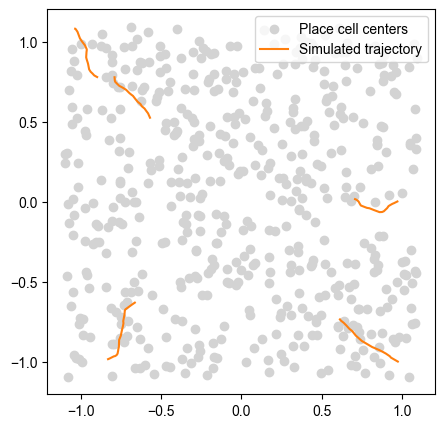

In [3]:
# Plot a few sample trajectories
inputs, pos, pc_outputs = trajectory_generator.get_test_batch()
us  = place_cells.us.cpu()
pos = pos.cpu()

plt.figure(figsize=(5, 5))
plt.scatter(us[:, 0], us[:, 1], c='lightgrey', label='Place cell centers')
for i in range(5):
    plt.plot(pos[:, i, 0], pos[:, i, 1], label='Simulated trajectory', c='C1')
    if i == 0:
        plt.legend()

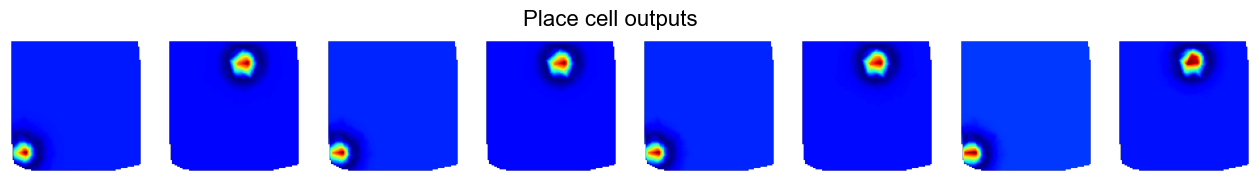

In [4]:
# Plot a few place cell outputs
pc_outputs = pc_outputs.reshape(-1, options.Np).detach().cpu()
pc = place_cells.grid_pc(pc_outputs[::100], res=100)

plt.figure(figsize=(16, 2))
for i in range(8):
    plt.subplot(1, 8, i + 1)
    plt.imshow(pc[i], cmap='jet')
    plt.axis('off')

plt.suptitle('Place cell outputs', fontsize=16)
plt.show()

(np.float64(-0.5), np.float64(10.5), np.float64(-0.5), np.float64(10.5))

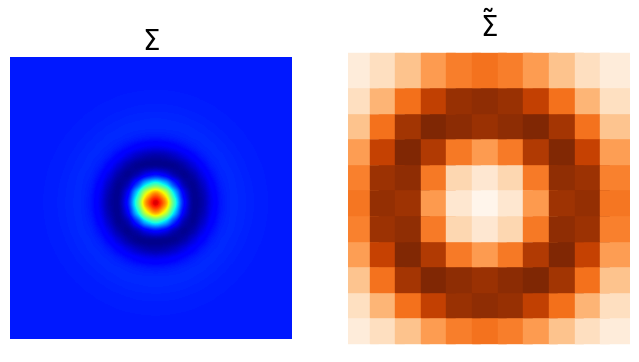

In [5]:
# Visualize place cell covariance matrix
Cmean = place_cells.compute_covariance(res=30)

# Fourier transform
Ctilde = np.fft.fft2(Cmean)
Ctilde[0, 0] = 0

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(Cmean, cmap='jet', interpolation='gaussian')
plt.axis('off')
plt.title(r'$\Sigma$', fontsize=20)

plt.subplot(122)
width = 6
idxs = np.arange(-width + 1, width)
x2, y2 = np.meshgrid(np.arange(2 * width - 1), np.arange(2 * width - 1))
plt.scatter(x2, y2, c=np.abs(Ctilde)[idxs][:, idxs],
            s=600, cmap='Oranges', marker='s')
plt.axis('equal')
plt.axis('off')
plt.title(r'$\tilde \Sigma$', fontsize=20)
plt.axis('off')

### Evaluate performance

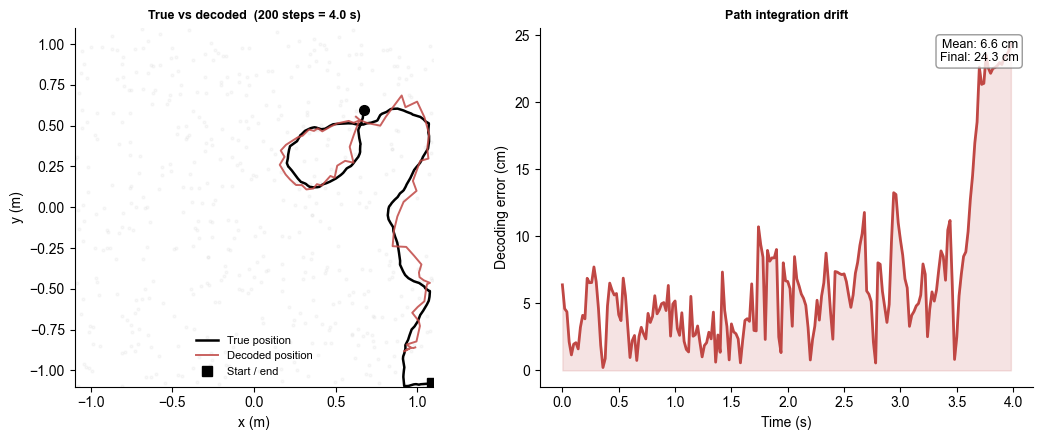

In [6]:
# ── Single long trajectory — true vs decoded position ─────────────────────────
# Temporarily extend sequence_length to show path integration over a longer
# window. The model was trained on 20-step (0.4 s) trajectories; longer sequences
# reveal how decoding error accumulates (path integration drift).
#
# Note: batch_size=1 triggers a squeeze() bug in the trajectory generator that
# collapses the batch dimension → use batch_size=2 and keep only the first trajectory.

LONG_SEQ = 200   # steps at dt=20 ms → 4 seconds

options.sequence_length = LONG_SEQ
traj_gen_long = TrajectoryGenerator(options, place_cells)

with torch.no_grad():
    inputs_l, pos_l, _ = traj_gen_long.get_test_batch(batch_size=2)
    pred_l_full = place_cells.get_nearest_cell_pos(model.predict(inputs_l)).cpu().numpy()

pos_l_np = pos_l.cpu().numpy()[:, :1, :]   # (LONG_SEQ, 1, 2) — first trajectory
pred_l   = pred_l_full[:, :1, :]
us_np    = place_cells.us.cpu().numpy()
t_axis   = np.arange(LONG_SEQ) * 0.02      # seconds

# Restore original sequence length
options.sequence_length = 20

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Spatial: true vs decoded
axes[0].scatter(us_np[:, 0], us_np[:, 1], s=4, alpha=0.15, color='lightgrey')
axes[0].plot(pos_l_np[:, 0, 0], pos_l_np[:, 0, 1],
             color='k', lw=1.8, label='True position', zorder=3)
axes[0].plot(pred_l[:, 0, 0], pred_l[:, 0, 1],
             color='#c04744', lw=1.4, alpha=0.85, label='Decoded position', zorder=4)
axes[0].plot(*pos_l_np[0, 0],  'o', color='k', ms=7, zorder=5)
axes[0].plot(*pos_l_np[-1, 0], 's', color='k', ms=7, zorder=5, label='Start / end')
axes[0].set_aspect('equal')
axes[0].set_xlim(-options.box_width/2,  options.box_width/2)
axes[0].set_ylim(-options.box_height/2, options.box_height/2)
axes[0].legend(fontsize=8, frameon=False)
axes[0].set_title(f'True vs decoded  ({LONG_SEQ} steps = {LONG_SEQ*0.02:.1f} s)',
                   fontsize=9, fontweight='bold')
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('y (m)')
axes[0].spines[['top','right']].set_visible(False)

# Error over time
err = np.sqrt(((pos_l_np[:, 0, :] - pred_l[:, 0, :])**2).sum(-1)) * 100  # cm
axes[1].plot(t_axis, err, color='#c04744', lw=2)
axes[1].fill_between(t_axis, 0, err, color='#c04744', alpha=0.15)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Decoding error (cm)')
axes[1].set_title('Path integration drift', fontsize=9, fontweight='bold')
axes[1].text(0.97, 0.97, f'Mean: {err.mean():.1f} cm\nFinal: {err[-1]:.1f} cm',
             transform=axes[1].transAxes, va='top', ha='right', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.8))
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

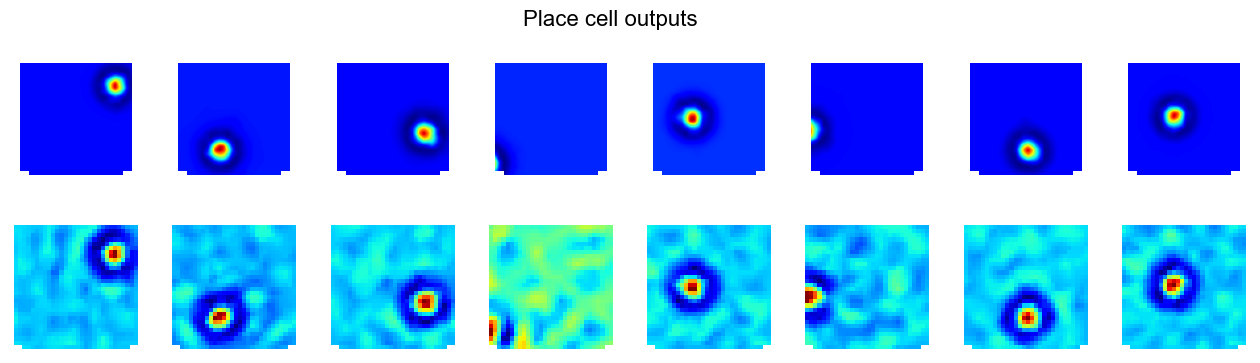

In [7]:
# Visualize predicted place cell outputs
inputs, pos, pc_outputs = trajectory_generator.get_test_batch()
preds      = model.predict(inputs)
preds      = preds.reshape(-1, options.Np).detach().cpu()
pc_outputs = model.softmax(pc_outputs).reshape(-1, options.Np).cpu()
pc_pred    = place_cells.grid_pc(preds[:100])
pc         = place_cells.grid_pc(pc_outputs[:100])

plt.figure(figsize=(16, 4))
for i in range(8):
    plt.subplot(2, 8, i + 9)
    plt.imshow(pc_pred[2 * i], cmap='jet')
    if i == 0:
        plt.ylabel('Predicted')
    plt.axis('off')
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(pc[2 * i], cmap='jet', interpolation='gaussian')
    if i == 0:
        plt.ylabel('True')
    plt.axis('off')
plt.suptitle('Place cell outputs', fontsize=16)
plt.show()

## 2. Rate maps and grid scores

In [8]:
RES   = 40
N_AVG = 1000 // options.sequence_length
N_RM  = 512   # units to compute rate maps for (subset of Ng=4096 for speed)

print(f'Computing rate maps for {N_RM} of {options.Ng} hidden units...')
with torch.no_grad():
    activations, rate_map, _, _ = compute_ratemaps(
        model, trajectory_generator, options,
        res=RES, n_avg=N_AVG, Ng=N_RM)

starts      = [0.2] * 10
ends        = np.linspace(0.4, 1.0, num=10)
coord_range = ((-options.box_width/2,  options.box_width/2),
               (-options.box_height/2, options.box_height/2))
scorer      = GridScorer(RES, coord_range, zip(starts, ends.tolist()))

score_60, score_90 = [], []
for ni in tqdm(range(N_RM), desc='Grid scores'):
    s60, s90, *_ = scorer.get_scores(activations[ni])
    score_60.append(s60); score_90.append(s90)
score_60 = np.array(score_60)
score_90 = np.array(score_90)

GRID_THRESH = 0.3
is_grid     = score_60 > GRID_THRESH
grid_idx    = np.where( is_grid)[0][np.argsort(score_60[ is_grid])[::-1]]
nongrid_idx = np.where(~is_grid)[0][np.argsort(score_60[~is_grid])[::-1]]

print(f'Of {N_RM} sampled units:  '
      f'{is_grid.sum()} GC (score>{GRID_THRESH})   '
      f'{(~is_grid).sum()} NG')
print(f'Note: {options.Ng - N_RM} additional hidden units not shown '
      f'(increase N_RM to include more, at proportionally longer compute time)')

Computing rate maps for 512 of 4096 hidden units...


Grid scores: 100%|██████████| 512/512 [01:23<00:00,  6.11it/s]

Of 512 sampled units:  335 GC (score>0.3)   177 NG
Note: 3584 additional hidden units not shown (increase N_RM to include more, at proportionally longer compute time)


## 3. Example rate maps — GC and NG cells

Peak threshold: 0.0368  (107/177 NG cells pass)
GC shown: 25  NG shown: 25  (score range -0.29–-0.04)


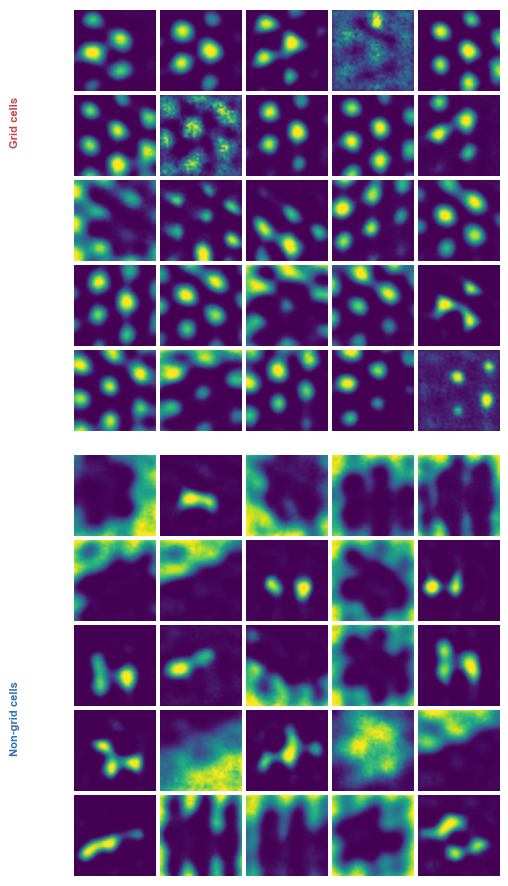

In [9]:
N_SHOW     = 25
COLS       = 5
ROWS_GROUP = N_SHOW // COLS

# ── GC: top 25 by grid score ───────────────────────────────────────────────
gc_show = grid_idx[:N_SHOW]

# ── NG: lowest grid scores that still have an okay firing rate ─────────────
# nongrid_idx is sorted descending (highest NG score first).
# We want the LOWEST scores → reverse to get most clearly non-grid cells first.
ng_lowest_first = nongrid_idx[::-1]   # lowest grid score first

peak_act    = np.array([np.nanpercentile(activations[ni], 99) for ni in range(len(activations))])
peak_thresh = np.median(peak_act) * 0.5
ng_valid    = ng_lowest_first[peak_act[ng_lowest_first] >= peak_thresh]

print(f'Peak threshold: {peak_thresh:.4f}  '
      f'({len(ng_valid)}/{len(nongrid_idx)} NG cells pass)')

# Take the N_SHOW lowest-scoring valid NG cells
ng_show = ng_valid[:N_SHOW]
print(f'GC shown: {len(gc_show)}  '
      f'NG shown: {len(ng_show)}  '
      f'(score range {score_60[ng_show].min():.2f}–{score_60[ng_show].max():.2f})')

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(COLS * 1.1, ROWS_GROUP * 2 * 1.1 + 0.25))
gs  = fig.add_gridspec(
    ROWS_GROUP * 2 + 1, COLS,
    hspace=0.05, wspace=0.04,
    height_ratios=[1]*ROWS_GROUP + [0.2] + [1]*ROWS_GROUP,
)

for row in range(ROWS_GROUP):
    for col in range(COLS):
        idx = row * COLS + col

        ax_gc = fig.add_subplot(gs[row, col])
        ni    = gc_show[idx]
        rm    = activations[ni]
        ax_gc.imshow(rm.T, origin='lower', cmap='viridis',
                     vmin=0, vmax=max(np.nanpercentile(rm, 99), 1e-4),
                     interpolation='gaussian')
        for spine in ax_gc.spines.values(): spine.set_visible(False)
        ax_gc.set_xticks([]); ax_gc.set_yticks([])

        ax_ng = fig.add_subplot(gs[row + ROWS_GROUP + 1, col])
        ni    = ng_show[idx]
        rm    = activations[ni]
        ax_ng.imshow(rm.T, origin='lower', cmap='viridis',
                     vmin=0, vmax=max(np.nanpercentile(rm, 99), 1e-4),
                     interpolation='gaussian')
        for spine in ax_ng.spines.values(): spine.set_visible(False)
        ax_ng.set_xticks([]); ax_ng.set_yticks([])

fig.text(0.01, 0.78, 'Grid cells', va='center', rotation=90,
         fontsize=8, fontweight='bold', color='#c04744')
fig.text(0.01, 0.25, 'Non-grid cells', va='center', rotation=90,
         fontsize=8, fontweight='bold', color='#3171ae')
plt.show()

Dominant spatial frequency: k=(np.int64(3), np.int64(0))


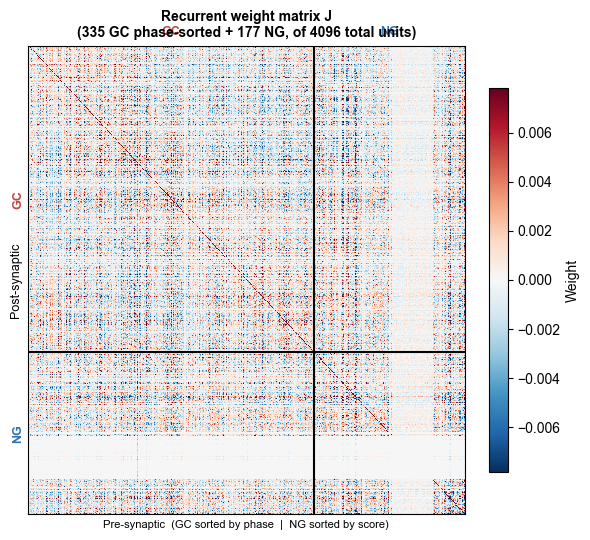

In [10]:
# ── Sort GC cells by grid phase ───────────────────────────────────────────────
# Phase is extracted from the FFT of each GC's rate map at the dominant
# spatial frequency.  Cells with similar phase fire at overlapping locations;
# sorting by phase reveals any phase-dependent structure in J.

# FFT of all GC rate maps
rm_fft_gc = np.array([np.fft.fft2(activations[ni]) for ni in grid_idx])  # (n_gc, RES, RES)

# Dominant spatial frequency: peak of mean power (excluding DC and upper half)
mean_power        = (np.abs(rm_fft_gc)**2).mean(0)
mean_power[0, 0]  = 0
half              = RES // 2
k_peak            = np.unravel_index(mean_power[:half, :half].argmax(), (half, half))
print(f'Dominant spatial frequency: k={k_peak}')

# Phase at dominant frequency for each GC, then sort
phase_gc          = np.angle(rm_fft_gc[:, k_peak[0], k_peak[1]])   # (n_gc,)
gc_phase_order    = np.argsort(phase_gc)
grid_idx_sorted   = grid_idx[gc_phase_order]   # GC indices sorted by phase

# ── Build sorted connectivity sub-matrix ──────────────────────────────────────
# Rows/cols: GC (phase-sorted) | NG (grid-score sorted)
J_full   = model.RNN.weight_hh_l0.detach().cpu().numpy()   # (Ng, Ng)
rm_order = np.concatenate([grid_idx_sorted, nongrid_idx])
n_gc_rm  = len(grid_idx_sorted)
n_ng_rm  = len(nongrid_idx)

J_sorted = J_full[np.ix_(rm_order, rm_order)]
vmax     = np.percentile(np.abs(J_sorted), 99)

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(J_sorted, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               interpolation='nearest', aspect='auto')

ax.axhline(n_gc_rm - 0.5, color='k', lw=1.5)
ax.axvline(n_gc_rm - 0.5, color='k', lw=1.5)

plt.colorbar(im, ax=ax, fraction=0.04, label='Weight')

ax.text(n_gc_rm / 2,            -12, 'GC',  ha='center', fontsize=9,
         fontweight='bold', color='#c04744')
ax.text(n_gc_rm + n_ng_rm / 2,  -12, 'NG',  ha='center', fontsize=9,
         fontweight='bold', color='#3171ae')
ax.text(-12, n_gc_rm / 2,        'GC',  ha='center', va='center', fontsize=9,
         fontweight='bold', color='#c04744', rotation=90)
ax.text(-12, n_gc_rm + n_ng_rm / 2, 'NG', ha='center', va='center', fontsize=9,
         fontweight='bold', color='#3171ae', rotation=90)

ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel('Pre-synaptic  (GC sorted by phase  |  NG sorted by score)', fontsize=8)
ax.set_ylabel('Post-synaptic', fontsize=9)
ax.set_title(f'Recurrent weight matrix J\n'
              f'({n_gc_rm} GC phase-sorted + {n_ng_rm} NG, of {options.Ng} total units)',
              fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

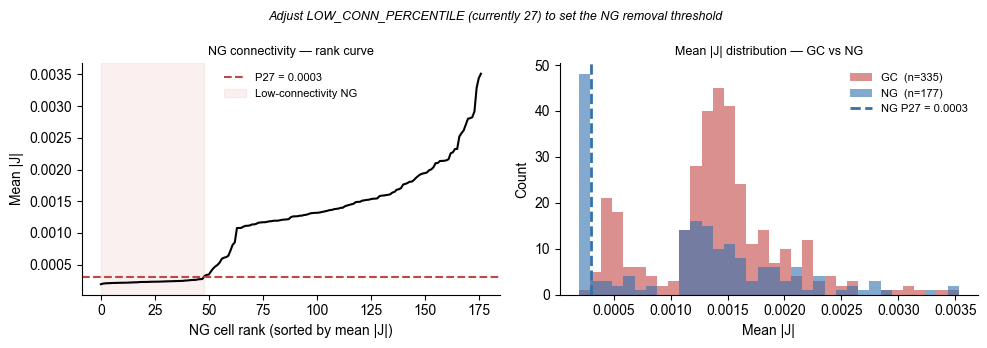

Removed 48 low-connectivity NG cells  |  129 NG retained  |  335 GC unchanged
Updated rm_order: 464 cells  (335 GC + 129 NG)


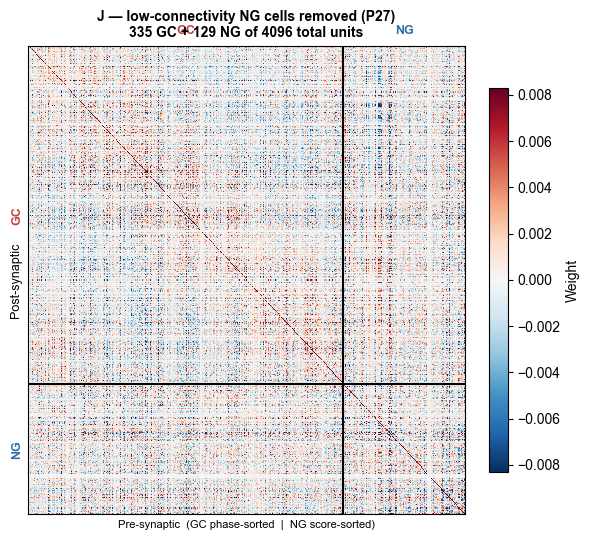

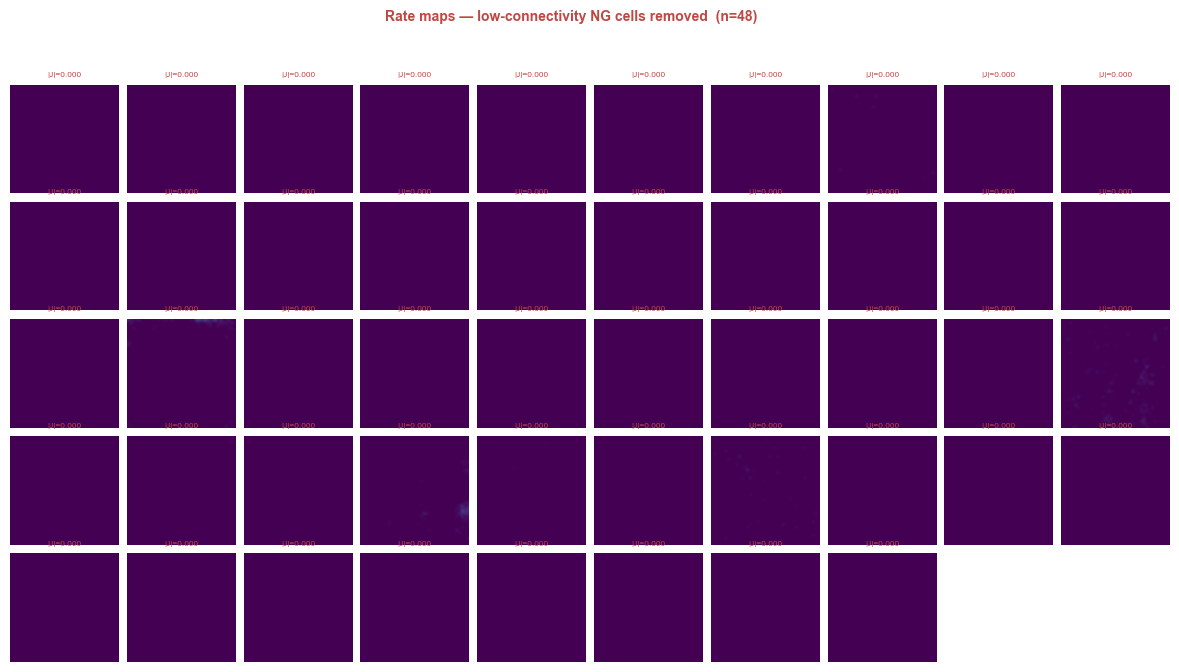

In [11]:
# ── Identify and remove low-connectivity NG cells ─────────────────────────────
# Some NG units have near-zero mean |J| across all connections — they are weakly
# coupled to the rest of the network (low connectivity). We identify them by
# computing each cell's mean |J| (incoming + outgoing), choose a percentile
# cutoff manually, and remove them. The filtered rm_order and J_sorted are
# reused by all downstream cells.

gc_pos  = np.arange(0, n_gc_rm)
ng_pos  = np.arange(n_gc_rm, len(rm_order))
ng_glob = rm_order[ng_pos]

gc_incoming = np.abs(J_sorted[gc_pos, :]).mean(axis=1)
gc_outgoing = np.abs(J_sorted[:, gc_pos]).mean(axis=0)
gc_mean_abs = (gc_incoming + gc_outgoing) / 2

ng_incoming = np.abs(J_sorted[ng_pos, :]).mean(axis=1)
ng_outgoing = np.abs(J_sorted[:, ng_pos]).mean(axis=0)
ng_mean_abs = (ng_incoming + ng_outgoing) / 2

# ── Set this manually after inspecting the plots below ────────────────────────
LOW_CONN_PERCENTILE = 27   # remove bottom N% of NG cells by mean |J|
# ─────────────────────────────────────────────────────────────────────────────

low_conn_thresh = np.percentile(ng_mean_abs, LOW_CONN_PERCENTILE)

# ── Distribution plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

sorted_weights = np.sort(ng_mean_abs)
axes[0].plot(sorted_weights, 'k-', lw=1.5)
axes[0].axhline(low_conn_thresh, color='#c04744', lw=1.5, ls='--',
                label=f'P{LOW_CONN_PERCENTILE} = {low_conn_thresh:.4f}')
axes[0].axvspan(0, LOW_CONN_PERCENTILE / 100 * len(ng_mean_abs),
                color='#c04744', alpha=0.08, label='Low-connectivity NG')
axes[0].set_xlabel('NG cell rank (sorted by mean |J|)'); axes[0].set_ylabel('Mean |J|')
axes[0].set_title('NG connectivity — rank curve', fontsize=9)
axes[0].legend(fontsize=8, frameon=False)
axes[0].spines[['top','right']].set_visible(False)

all_weights = np.concatenate([gc_mean_abs, ng_mean_abs])
bins = np.linspace(all_weights.min(), all_weights.max(), 35)
axes[1].hist(gc_mean_abs, bins=bins, color='#c04744', edgecolor='none',
             alpha=0.6, label=f'GC  (n={len(gc_mean_abs)})')
axes[1].hist(ng_mean_abs, bins=bins, color='#3171ae', edgecolor='none',
             alpha=0.6, label=f'NG  (n={len(ng_mean_abs)})')
axes[1].axvline(low_conn_thresh, color='#3171ae', lw=2, ls='--',
                label=f'NG P{LOW_CONN_PERCENTILE} = {low_conn_thresh:.4f}')
axes[1].set_xlabel('Mean |J|'); axes[1].set_ylabel('Count')
axes[1].set_title('Mean |J| distribution — GC vs NG', fontsize=9)
axes[1].legend(fontsize=8, frameon=False)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(f'Adjust LOW_CONN_PERCENTILE (currently {LOW_CONN_PERCENTILE}) '
              f'to set the NG removal threshold', fontsize=9, style='italic')
plt.tight_layout(); plt.show()

# ── Filter: keep NG cells ABOVE the threshold ─────────────────────────────────
keep_ng_mask      = ng_mean_abs > low_conn_thresh
keep_ng_glob      = ng_glob[keep_ng_mask]
low_conn_glob     = ng_glob[~keep_ng_mask]
low_conn_weights  = ng_mean_abs[~keep_ng_mask]
print(f'Removed {(~keep_ng_mask).sum()} low-connectivity NG cells  |  '
      f'{keep_ng_mask.sum()} NG retained  |  {n_gc_rm} GC unchanged')

# Overwrite rm_order and derived variables for all downstream cells
rm_order = np.concatenate([grid_idx_sorted, keep_ng_glob])
n_gc_rm  = len(grid_idx_sorted)
n_ng_rm  = len(keep_ng_glob)

J_full   = model.RNN.weight_hh_l0.detach().cpu().numpy()
J_sorted = J_full[np.ix_(rm_order, rm_order)]
vmax     = np.percentile(np.abs(J_sorted), 99)
print(f'Updated rm_order: {len(rm_order)} cells  ({n_gc_rm} GC + {n_ng_rm} NG)')

# ── Replot connectivity matrix without low-connectivity cells ─────────────────
fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(J_sorted, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
               interpolation='nearest', aspect='auto')
ax.axhline(n_gc_rm - 0.5, color='k', lw=1.5)
ax.axvline(n_gc_rm - 0.5, color='k', lw=1.5)
plt.colorbar(im, ax=ax, fraction=0.04, label='Weight')
ax.text(n_gc_rm / 2,            -12, 'GC', ha='center', fontsize=9,
         fontweight='bold', color='#c04744')
ax.text(n_gc_rm + n_ng_rm / 2,  -12, 'NG', ha='center', fontsize=9,
         fontweight='bold', color='#3171ae')
ax.text(-12, n_gc_rm / 2,        'GC', ha='center', va='center', fontsize=9,
         fontweight='bold', color='#c04744', rotation=90)
ax.text(-12, n_gc_rm + n_ng_rm / 2, 'NG', ha='center', va='center', fontsize=9,
         fontweight='bold', color='#3171ae', rotation=90)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel('Pre-synaptic  (GC phase-sorted  |  NG score-sorted)', fontsize=8)
ax.set_ylabel('Post-synaptic', fontsize=9)
ax.set_title(f'J — low-connectivity NG cells removed (P{LOW_CONN_PERCENTILE})\n'
              f'{n_gc_rm} GC + {n_ng_rm} NG of {options.Ng} total units',
              fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Rate maps for removed low-connectivity cells ──────────────────────────────
sort_lc       = np.argsort(low_conn_weights)
low_conn_glob = low_conn_glob[sort_lc]
low_conn_weights = low_conn_weights[sort_lc]
N_COLS = min(10, len(low_conn_glob))
N_ROWS = int(np.ceil(len(low_conn_glob) / max(N_COLS, 1)))
fig, axes_rm = plt.subplots(N_ROWS, N_COLS,
                              figsize=(N_COLS * 1.5, N_ROWS * 1.5),
                              gridspec_kw={'hspace': 0.08, 'wspace': 0.05})
axes_rm = np.array(axes_rm).reshape(N_ROWS, N_COLS)
for i, (ni, w) in enumerate(zip(low_conn_glob, low_conn_weights)):
    row, col = divmod(i, N_COLS)
    ax  = axes_rm[row, col]
    rm  = activations[ni]
    vmax_rm = np.nanpercentile(rm, 99)
    ax.imshow(rm.T, origin='lower', cmap='viridis',
               vmin=0, vmax=max(vmax_rm, 1e-4), interpolation='gaussian')
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'|J|={w:.3f}', fontsize=6, color='#c04744')
for i in range(len(low_conn_glob), N_ROWS * N_COLS):
    axes_rm.ravel()[i].set_visible(False)
fig.suptitle(f'Rate maps — low-connectivity NG cells removed  (n={len(low_conn_glob)})',
              fontsize=10, fontweight='bold', color='#c04744')
plt.show()

## Figure: J connectivity matrix vs pairwise XGBoost ΔpR²

### What and why

The recurrent weight matrix **J** of the trained RNN encodes the learned connectivity
between all hidden units. If XGBoost Δpρ² (the additional variance in one cell's
activity explained by another cell's history, above position) genuinely reflects
coordination driven by network connectivity, we expect it to mirror the structure
of J: strongly connected cell pairs should have higher Δpρ².

The figure has two panels with the **same cell ordering** in both axes so the two
matrices can be read side-by-side:

- **Top** — `J_sorted`: the full recurrent weight matrix for all N_RM sampled units.
  GC cells are sorted by grid phase (cells with similar phase fire at overlapping
  locations); NG cells are sorted by grid score. Phase-sorting of GC cells reveals
  the toroidal attractor structure of the CAN, where similarly-phased cells are more
  strongly connected.

- **Bottom** — `ΔpR² matrix`: for every ordered pair (covariate j → target i),
  `ΔpR² = pR²(position + j history) − pR²(position only)`. Positive values mean
  cell j's recent spike history helps predict cell i above their shared spatial drive.

### Why the XGBoost is cached

Running all N_RM × (N_RM − 1) pairs takes many hours. The results are saved to
a `.npz` file after every target cell completes. Re-running the cell skips already-
finished targets and continues from where it left off, so the analysis can be spread
across multiple sessions. Once `completed.all()` is True the figure can be generated.

In [12]:
# ── Parameters for full-network XGBoost ──────────────────────────────────────
N_ALL      = len(rm_order)
N_BATCHES_ALL  = 30
N_CV_ALL       = 3
WINDOW_MS_ALL  = 20
HISTORY_MS_ALL = 200
N_FILTERS_ALL  = 5

# Cache saved inside the project data directory so it persists across sessions
CACHE_DIR  = '/Users/harryclark/Documents/spatial-manifolds/data/rnn_xgboost'
CACHE_FILE = os.path.join(CACHE_DIR, 'pr2_full_network_cache.npz')
os.makedirs(CACHE_DIR, exist_ok=True)

xgb_all = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False,
                      window=WINDOW_MS_ALL, n_filters=N_FILTERS_ALL,
                      max_time=HISTORY_MS_ALL)

print(f'Full network analysis: {N_ALL} cells  →  {N_ALL*(N_ALL-1):,} pairs')
print(f'Cache: {CACHE_FILE}')

# ── Collect activations for all N_RM cells in rm_order ───────────────────────
print('\nCollecting activations...')
g_all_list, pos_all_list = [], []
model.eval()
with torch.no_grad():
    for _ in tqdm(range(N_BATCHES_ALL), desc='Activations (full network)'):
        inp, pos_b, _ = trajectory_generator.get_test_batch()
        g_b = model.g(inp).cpu().numpy().transpose(1, 0, 2).reshape(-1, options.Ng)
        p_b = pos_b.cpu().numpy().transpose(1, 0, 2).reshape(-1, 2)
        g_all_list.append(g_b[:, rm_order])
        pos_all_list.append(p_b)

G_all     = np.concatenate(g_all_list,   axis=0).astype(np.float32)
POS_all   = np.concatenate(pos_all_list, axis=0).astype(np.float32)
pos_n_all = (POS_all - POS_all.min(0)) / (POS_all.max(0) - POS_all.min(0) + 1e-8)
T_all     = len(G_all)
print(f'Collected  T={T_all:,} bins  ({T_all*WINDOW_MS_ALL/1000:.0f} s)')

Full network analysis: 464 cells  →  214,832 pairs
Cache: /Users/harryclark/Documents/spatial-manifolds/data/rnn_xgboost/pr2_full_network_cache.npz



Activations (full network): 100%|██████████| 30/30 [00:07<00:00,  4.06it/s]


Collected  T=120,000 bins  (2400 s)


In [13]:
# ── Cached pairwise XGBoost — pos / cell / pos+cell for every pair ────────────
# Three models per ordered pair (target i, covariate j):
#   pos      — position history only            (once per target, no covariate)
#   cell     — covariate j history only         (one cell as covariate, no position)
#   pos+cell — position + covariate j history   (one cell + position as covariates)
#
# Saves after every target. Re-running skips completed targets.

# ── Load or initialise cache ──────────────────────────────────────────────────
if os.path.exists(CACHE_FILE):
    cache          = np.load(CACHE_FILE)
    pr2_pos_all    = cache['pr2_pos_all'].copy()    # (N_ALL,)
    pr2_cell_all   = cache['pr2_cell_all'].copy()   # (N_ALL, N_ALL)
    pr2_full_all   = cache['pr2_full_all'].copy()   # (N_ALL, N_ALL)
    completed_all  = cache['completed_all'].copy()  # (N_ALL,) bool
    n_done = int(completed_all.sum())
    print(f'Cache loaded: {n_done}/{N_ALL} targets complete  '
          f'({N_ALL - n_done} remaining)')
else:
    pr2_pos_all   = np.full((N_ALL,),       np.nan, dtype=np.float32)
    pr2_cell_all  = np.full((N_ALL, N_ALL), np.nan, dtype=np.float32)
    pr2_full_all  = np.full((N_ALL, N_ALL), np.nan, dtype=np.float32)
    completed_all = np.zeros(N_ALL, dtype=bool)
    print(f'Starting fresh: {N_ALL} targets  ({N_ALL*(N_ALL-1):,} pairs total)')

# ── ETA estimate ──────────────────────────────────────────────────────────────
first_incomplete = np.where(~completed_all)[0]
if len(first_incomplete) > 0:
    t_bench = time.time()
    ti_b    = int(first_incomplete[0])
    y_b     = G_all[:, ti_b]
    # Time 1 pos fit + 3 × (cell + pos+cell) fits, then scale to full target
    xgb_all.fit_cv(pos_n_all, y_b, verbose=0, continuous_folds=True, n_cv=N_CV_ALL)
    for ci in range(min(3, N_ALL - 1)):
        ci_b = ci if ci != ti_b else ci + 1
        cov  = G_all[:, ci_b][:, None]
        xgb_all.fit_cv(cov,                               y_b, verbose=0, continuous_folds=True, n_cv=N_CV_ALL)
        xgb_all.fit_cv(np.column_stack([pos_n_all, cov]), y_b, verbose=0, continuous_folds=True, n_cv=N_CV_ALL)
    t_per_target = (time.time() - t_bench) * (N_ALL - 1) / 3
    remaining    = int((~completed_all).sum())
    print(f'ETA: {t_per_target * remaining / 3600:.1f} h  '
          f'({t_per_target / 60:.1f} min per target × {remaining} remaining)')

# ── Main loop ─────────────────────────────────────────────────────────────────
t_start = time.time()
for ti in range(N_ALL):
    if completed_all[ti]:
        continue

    y = G_all[:, ti]

    # pos model — fitted once per target (same baseline for all covariates)
    _, pr2_pos = xgb_all.fit_cv(pos_n_all, y, verbose=0,
                                  continuous_folds=True, n_cv=N_CV_ALL)
    pr2_pos_all[ti] = float(np.nanmean(pr2_pos))

    # cell and pos+cell models — fitted once per pair with a single covariate cell
    for ci in range(N_ALL):
        if ci == ti: continue
        cov = G_all[:, ci][:, None]   # single cell, shape (T, 1)

        _, pr2_cell = xgb_all.fit_cv(cov,                               y, verbose=0,
                                       continuous_folds=True, n_cv=N_CV_ALL)
        _, pr2_full = xgb_all.fit_cv(np.column_stack([pos_n_all, cov]), y, verbose=0,
                                       continuous_folds=True, n_cv=N_CV_ALL)

        pr2_cell_all[ci, ti] = float(np.nanmean(pr2_cell))
        pr2_full_all[ci, ti] = float(np.nanmean(pr2_full))

    completed_all[ti] = True

    # Save after every target
    np.savez(CACHE_FILE,
             pr2_pos_all=pr2_pos_all,
             pr2_cell_all=pr2_cell_all,
             pr2_full_all=pr2_full_all,
             completed_all=completed_all)

    n_done  = int(completed_all.sum())
    elapsed = (time.time() - t_start) / 60
    delta   = pr2_full_all - pr2_pos_all[None, :]
    print(f'  [{n_done}/{N_ALL}] target {ti}  '
          f'elapsed={elapsed:.1f} min  '
          f'max ΔpR²={np.nanmax(delta):.4f}',
          flush=True)

print(f'\n{"All targets complete!" if completed_all.all() else f"{int(completed_all.sum())}/{N_ALL} done — rerun to continue"}')

Cache loaded: 278/464 targets complete  (186 remaining)
ETA: 124.4 h  (40.1 min per target × 186 remaining)
  [279/464] target 278  elapsed=28.7 min  max ΔpR²=0.9755
  [280/464] target 279  elapsed=50.6 min  max ΔpR²=0.9755
  [281/464] target 280  elapsed=77.4 min  max ΔpR²=0.9755
  [282/464] target 281  elapsed=103.0 min  max ΔpR²=0.9755
  [283/464] target 282  elapsed=130.9 min  max ΔpR²=0.9755
  [284/464] target 283  elapsed=187.1 min  max ΔpR²=0.9755
  [285/464] target 284  elapsed=222.2 min  max ΔpR²=0.9755
  [286/464] target 285  elapsed=245.0 min  max ΔpR²=0.9755
  [287/464] target 286  elapsed=263.3 min  max ΔpR²=0.9755
  [288/464] target 287  elapsed=279.8 min  max ΔpR²=0.9755
  [289/464] target 288  elapsed=292.2 min  max ΔpR²=0.9755
  [290/464] target 289  elapsed=309.4 min  max ΔpR²=0.9755
  [291/464] target 290  elapsed=325.9 min  max ΔpR²=0.9755
  [292/464] target 291  elapsed=342.2 min  max ΔpR²=0.9755
  [293/464] target 292  elapsed=359.1 min  max ΔpR²=0.9755
  [294/464

In [14]:
# ── Build DataFrame from cache for LMM analysis ──────────────────────────────
# Requires the cache to have at least some completed targets.
# Pairs with NaN ΔpR² (not yet computed) are dropped automatically.

if not os.path.exists(CACHE_FILE):
    print('No cache found — run the XGBoost cell first.')
else:
    cache         = np.load(CACHE_FILE)
    pr2_pos_all   = cache['pr2_pos_all'].copy()
    pr2_full_all  = cache['pr2_full_all'].copy()
    completed_all = cache['completed_all'].copy()
    delta_all     = pr2_full_all - pr2_pos_all[None, :]

    # Cell-type labels in rm_order: first n_gc_rm = GC, rest = NG
    is_gc_all = np.array([True]*n_gc_rm + [False]*n_ng_rm)

    rows = []
    for i in range(N_ALL):
        for j in range(N_ALL):
            if i == j or np.isnan(delta_all[j, i]): continue
            j_val = float(J_sorted[i, j])
            if j_val > 0:   sign = 'excitatory'
            elif j_val < 0: sign = 'inhibitory'
            else:            sign = 'zero'
            rows.append(dict(
                delta_pr2 = float(delta_all[j, i]),
                J_raw     = j_val,
                target_id = str(i),
                source_id = str(j),
                sign      = sign,
                conn_type = ('GC' if is_gc_all[j] else 'NG') + '→' +
                            ('GC' if is_gc_all[i] else 'NG'),
            ))

    df_tr = pd.DataFrame(rows)
    df_tr = df_tr[df_tr['sign'] != 'zero'].copy()

    n_done = int(completed_all.sum())
    print(f'Cache: {n_done}/{N_ALL} targets complete  |  {len(df_tr):,} valid pairs')
    print(df_tr['conn_type'].value_counts().to_string())


Cache: 464/464 targets complete  |  212,980 valid pairs
conn_type
GC→GC    111890
NG→GC     43215
GC→NG     41875
NG→NG     16000


In [15]:
# ── Fit LMM and compute partial residuals ────────────────────────────────────
import statsmodels.formula.api as smf

fits_tr = {}
for sign in ['excitatory', 'inhibitory']:
    s   = df_tr[df_tr['sign'] == sign]
    fit = smf.mixedlm('delta_pr2 ~ J_raw', s, groups=s['target_id']).fit(
            reml=True, method='lbfgs', disp=False)
    fits_tr[sign] = fit
    print(f'[{sign}]  β={fit.params["J_raw"]:.4f}  p={fit.pvalues["J_raw"]:.2e}')

# Partial residuals (remove target-cell random intercept)
for sign in ['excitatory', 'inhibitory']:
    re   = {k: float(v.iloc[0]) for k, v in fits_tr[sign].random_effects.items()}
    mask = df_tr['sign'] == sign
    df_tr.loc[mask, 're'] = df_tr.loc[mask, 'target_id'].map(re)
df_tr['partial_y'] = df_tr['delta_pr2'] - df_tr['re'].fillna(0)


[excitatory]  β=5.7212  p=0.00e+00


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


[inhibitory]  β=-2.3693  p=8.29e-77


464/464 targets complete  (100%)  max ΔpR²=0.9755


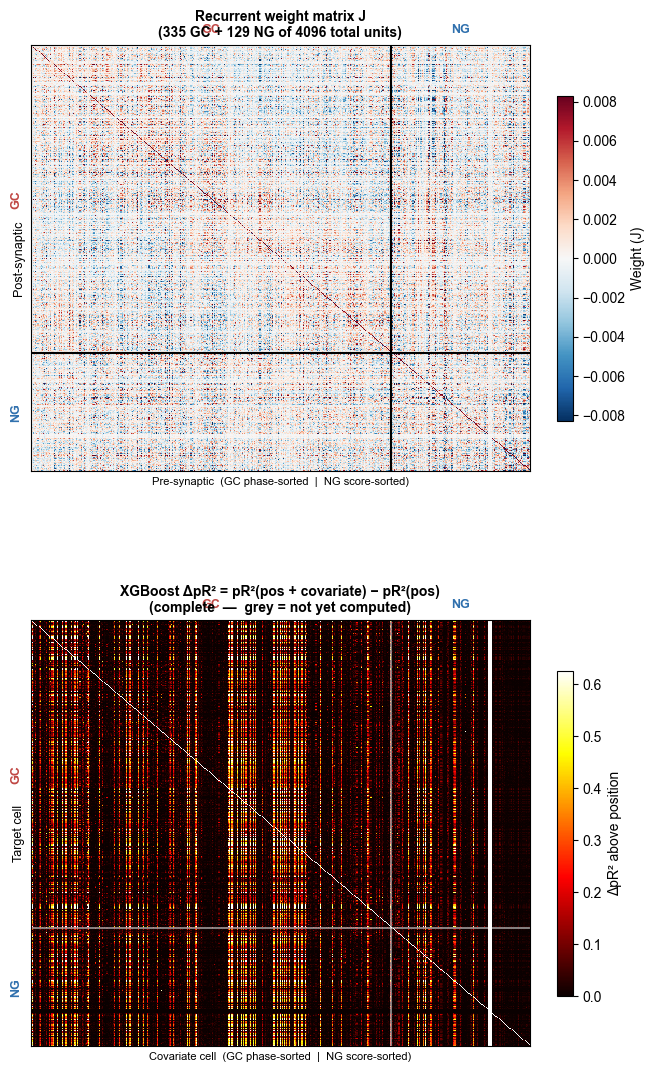

In [16]:
# ── Figure: J matrix (top) vs ΔpR² matrix (bottom) ───────────────────────────
# Both panels use the same rm_order axis → GC phase-sorted | NG score-sorted
# so structure can be compared directly between the two matrices.
# Partially-complete ΔpR² matrices are shown with NaN regions greyed out.

# Load latest cache if not already in memory
if not os.path.exists(CACHE_FILE):
    print('No cache found — run the XGBoost cell first.')
else:
    if 'pr2_full_all' not in dir() or pr2_full_all is None:
        cache         = np.load(CACHE_FILE)
        pr2_pos_all   = cache['pr2_pos_all']
        pr2_cell_all  = cache['pr2_cell_all']
        pr2_full_all  = cache['pr2_full_all']
        completed_all = cache['completed_all']

    delta_all = pr2_full_all - pr2_pos_all[None, :]   # (N_ALL, N_ALL)
    n_done    = int(completed_all.sum())
    print(f'{n_done}/{N_ALL} targets complete  '
          f'({n_done/N_ALL*100:.0f}%)'
          f'  max ΔpR²={np.nanmax(delta_all):.4f}')

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, (ax_J, ax_pr2, ax_cell) = plt.subplots(
        3, 1, figsize=(7, 19),
        gridspec_kw={'hspace': 0.35}
    )

    # ── Top panel: J connectivity matrix ──────────────────────────────────────
    vmax_J = np.percentile(np.abs(J_sorted), 99)
    im_J   = ax_J.imshow(J_sorted, cmap='RdBu_r', vmin=-vmax_J, vmax=vmax_J,
                          interpolation='nearest', aspect='auto')
    ax_J.axhline(n_gc_rm - 0.5, color='k', lw=1.5)
    ax_J.axvline(n_gc_rm - 0.5, color='k', lw=1.5)
    plt.colorbar(im_J, ax=ax_J, fraction=0.03, label='Weight (J)')

    ax_J.text(n_gc_rm / 2,           -14, 'GC',
               ha='center', fontsize=9, fontweight='bold', color='#c04744')
    ax_J.text(n_gc_rm + n_ng_rm / 2, -14, 'NG',
               ha='center', fontsize=9, fontweight='bold', color='#3171ae')
    ax_J.text(-14, n_gc_rm / 2,        'GC',
               ha='center', va='center', fontsize=9,
               fontweight='bold', color='#c04744', rotation=90)
    ax_J.text(-14, n_gc_rm + n_ng_rm / 2, 'NG',
               ha='center', va='center', fontsize=9,
               fontweight='bold', color='#3171ae', rotation=90)

    ax_J.set_xticks([]); ax_J.set_yticks([])
    ax_J.set_xlabel('Pre-synaptic  (GC phase-sorted  |  NG score-sorted)', fontsize=8)
    ax_J.set_ylabel('Post-synaptic', fontsize=9)
    ax_J.set_title(f'Recurrent weight matrix J\n'
                    f'({n_gc_rm} GC + {n_ng_rm} NG of {options.Ng} total units)',
                    fontsize=10, fontweight='bold')

    # ── Bottom panel: ΔpR² matrix ──────────────────────────────────────────────
    vmax_d = np.nanpercentile(np.abs(delta_all), 99)
    cmap_d = plt.cm.hot.copy(); cmap_d.set_bad('lightgrey')

    im_pr2 = ax_pr2.imshow(delta_all, cmap='hot', vmin=0, vmax=vmax_d,
                             interpolation='nearest', aspect='auto')
    ax_pr2.axhline(n_gc_rm - 0.5, color='white', lw=1.2, alpha=0.6)
    ax_pr2.axvline(n_gc_rm - 0.5, color='white', lw=1.2, alpha=0.6)
    plt.colorbar(im_pr2, ax=ax_pr2, fraction=0.03, label='ΔpR² above position')

    ax_pr2.text(n_gc_rm / 2,           -14, 'GC',
                 ha='center', fontsize=9, fontweight='bold', color='#c04744')
    ax_pr2.text(n_gc_rm + n_ng_rm / 2, -14, 'NG',
                 ha='center', fontsize=9, fontweight='bold', color='#3171ae')
    ax_pr2.text(-14, n_gc_rm / 2,        'GC',
                 ha='center', va='center', fontsize=9,
                 fontweight='bold', color='#c04744', rotation=90)
    ax_pr2.text(-14, n_gc_rm + n_ng_rm / 2, 'NG',
                 ha='center', va='center', fontsize=9,
                 fontweight='bold', color='#3171ae', rotation=90)

    ax_pr2.set_xticks([]); ax_pr2.set_yticks([])
    ax_pr2.set_xlabel('Covariate cell  (GC phase-sorted  |  NG score-sorted)', fontsize=8)
    ax_pr2.set_ylabel('Target cell', fontsize=9)
    progress = f'{n_done}/{N_ALL} targets' if not completed_all.all() else 'complete'
    ax_pr2.set_title(f'XGBoost ΔpR² = pR²(pos + covariate) − pR²(pos)\n'
                      f'({progress}  —  grey = not yet computed)',
                      fontsize=10, fontweight='bold')

    # ── Third panel: pR²(cell) matrix ─────────────────────────────────────
    vmax_c  = np.nanpercentile(np.abs(pr2_cell_all), 99)
    cmap_c  = plt.cm.Blues.copy(); cmap_c.set_bad('lightgrey')
    im_cell = ax_cell.imshow(pr2_cell_all, cmap=cmap_c, vmin=0, vmax=vmax_c,
                              interpolation='nearest', aspect='auto')
    ax_cell.axhline(n_gc_rm - 0.5, color='white', lw=1.2, alpha=0.6)
    ax_cell.axvline(n_gc_rm - 0.5, color='white', lw=1.2, alpha=0.6)
    plt.colorbar(im_cell, ax=ax_cell, fraction=0.03, label='pR²(cell)')

    ax_cell.text(n_gc_rm / 2,           -14, 'GC',
                 ha='center', fontsize=9, fontweight='bold', color='#c04744')
    ax_cell.text(n_gc_rm + n_ng_rm / 2, -14, 'NG',
                 ha='center', fontsize=9, fontweight='bold', color='#3171ae')
    ax_cell.text(-14, n_gc_rm / 2,        'GC',
                 ha='center', va='center', fontsize=9,
                 fontweight='bold', color='#c04744', rotation=90)
    ax_cell.text(-14, n_gc_rm + n_ng_rm / 2, 'NG',
                 ha='center', va='center', fontsize=9,
                 fontweight='bold', color='#3171ae', rotation=90)

    ax_cell.set_xticks([]); ax_cell.set_yticks([])
    ax_cell.set_xlabel('Covariate cell  (GC phase-sorted  |  NG score-sorted)', fontsize=8)
    ax_cell.set_ylabel('Target cell', fontsize=9)
    ax_cell.set_title('pR²(cell only)\n(cell spike trains, no position)',
                      fontsize=10, fontweight='bold')

    plt.savefig(os.path.join(CACHE_DIR, 'gcgc_matrices.pdf'),
                bbox_inches='tight', dpi=150)
    plt.show()

Fitting piecewise LMMs...


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



── β coefficients ──
GC→GC:  β_exc= 7.4532 p=0.00e+00  β_inh=-2.6934 p=7.17e-43
GC→NG:  β_exc= 4.3192 p=3.29e-99  β_inh=-1.7049 p=4.15e-19
NG→GC:  β_exc= 4.2842 p=2.27e-50  β_inh=-1.6623 p=1.59e-10
NG→NG:  β_exc= 3.3948 p=3.90e-41  β_inh=-1.5162 p=4.39e-10


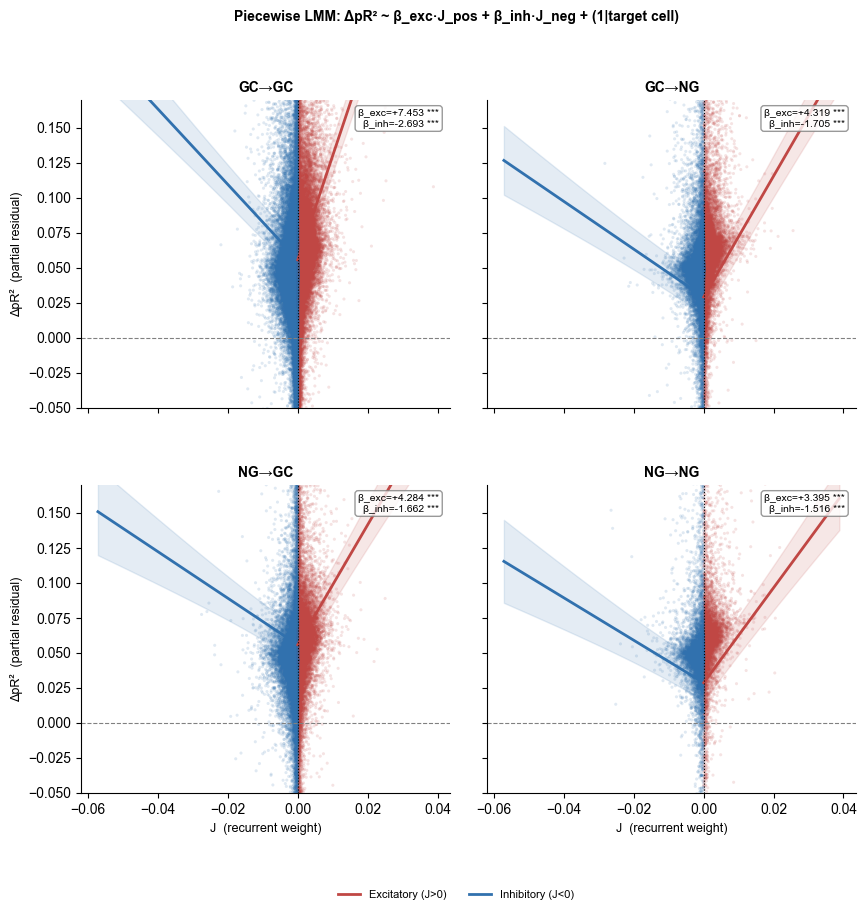

In [17]:
import statsmodels.formula.api as smf
import scipy.stats

CONN_TYPES = ['GC→GC', 'GC→NG', 'NG→GC', 'NG→NG']

def fit_piecewise(df):
    results = {}
    for ct in CONN_TYPES:
        sub = df[df['conn_type'] == ct].copy()
        sub['J_pos'] = sub['J_raw'].clip(lower=0)
        sub['J_neg'] = sub['J_raw'].clip(upper=0)
        fit = smf.mixedlm("delta_pr2 ~ J_pos + J_neg", sub,
                           groups=sub['target_id']).fit(
                               reml=True, method='lbfgs', disp=False)
        results[ct] = {'fit': fit, 'sub': sub}
    return results


def piecewise_line_ci(fit, x_neg_range, x_pos_range, ci=0.95):
    b0    = fit.params['Intercept']
    cov   = fit.cov_params()
    tc    = scipy.stats.t.ppf((1 + ci) / 2, df=fit.nobs - 2)

    def segment(x, key):
        y  = b0 + fit.params[key] * x
        X  = np.column_stack([np.ones_like(x), x])
        C  = cov.loc[['Intercept', key], ['Intercept', key]].values
        se = np.sqrt((X @ C * X).sum(axis=1))
        return y, tc * se

    x_n = np.linspace(x_neg_range, 0, 150)
    x_p = np.linspace(0, x_pos_range, 150)
    y_n, ci_n = segment(x_n, 'J_neg')
    y_p, ci_p = segment(x_p, 'J_pos')
    return x_n, y_n, ci_n, x_p, y_p, ci_p


print('Fitting piecewise LMMs...')
res_tr = fit_piecewise(df_tr)

print('\n── β coefficients ──')
for ct in CONN_TYPES:
    ft = res_tr[ct]['fit']
    print(f'{ct}:  β_exc={ft.params["J_pos"]: .4f} p={ft.pvalues["J_pos"]:.2e}  '
          f'β_inh={ft.params["J_neg"]: .4f} p={ft.pvalues["J_neg"]:.2e}')

# ── Figure ────────────────────────────────────────────────────────────────────
EXC_COL = '#c04744'
INH_COL = '#3171ae'

def pstar(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True,
                          gridspec_kw={'hspace': 0.25, 'wspace': 0.10})

j_all = np.concatenate([res_tr[ct]['sub']['J_raw'].values for ct in CONN_TYPES])
j_min, j_max = j_all.min(), j_all.max()

for idx, (ax, ct) in enumerate(zip(axes.ravel(), CONN_TYPES)):
    row, col = divmod(idx, 2)
    sub = res_tr[ct]['sub']
    jv  = sub['J_raw'].values
    py  = sub['partial_y'].values

    pos_mask = jv >= 0; neg_mask = jv < 0
    ax.scatter(jv[pos_mask], py[pos_mask], s=5, alpha=0.15, color=EXC_COL,
               edgecolors='none', rasterized=True)
    ax.scatter(jv[neg_mask], py[neg_mask], s=5, alpha=0.15, color=INH_COL,
               edgecolors='none', rasterized=True)

    fit = res_tr[ct]['fit']
    x_n, y_n, ci_n, x_p, y_p, ci_p = piecewise_line_ci(fit, j_min, j_max)
    ax.plot(x_n, y_n, color=INH_COL, lw=2)
    ax.plot(x_p, y_p, color=EXC_COL, lw=2)
    ax.fill_between(x_n, y_n - ci_n, y_n + ci_n, color=INH_COL, alpha=0.13)
    ax.fill_between(x_p, y_p - ci_p, y_p + ci_p, color=EXC_COL, alpha=0.13)

    b_exc = fit.params['J_pos']; p_exc = fit.pvalues['J_pos']
    b_inh = fit.params['J_neg']; p_inh = fit.pvalues['J_neg']
    ax.text(0.97, 0.97,
            f'β_exc={b_exc:+.3f} {pstar(p_exc)}\nβ_inh={b_inh:+.3f} {pstar(p_inh)}',
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.8))

    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.axvline(0, color='k',    lw=0.8, ls=':')
    ax.set_title(ct, fontsize=10, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    if row == 1:
        ax.set_xlabel('J  (recurrent weight)', fontsize=9)
    if col == 0:
        ax.set_ylabel('ΔpR²  (partial residual)', fontsize=9)

axes[0, 0].set_ylim(-0.05, 0.17)

from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], color=EXC_COL, lw=2, label='Excitatory (J>0)'),
    Line2D([0],[0], color=INH_COL, lw=2, label='Inhibitory (J<0)'),
]
fig.legend(handles=handles, fontsize=8, frameon=False,
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Piecewise LMM: ΔpR² ~ β_exc·J_pos + β_inh·J_neg + (1|target cell)',
             fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

Fitting piecewise LMMs...


/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/envs/sm/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


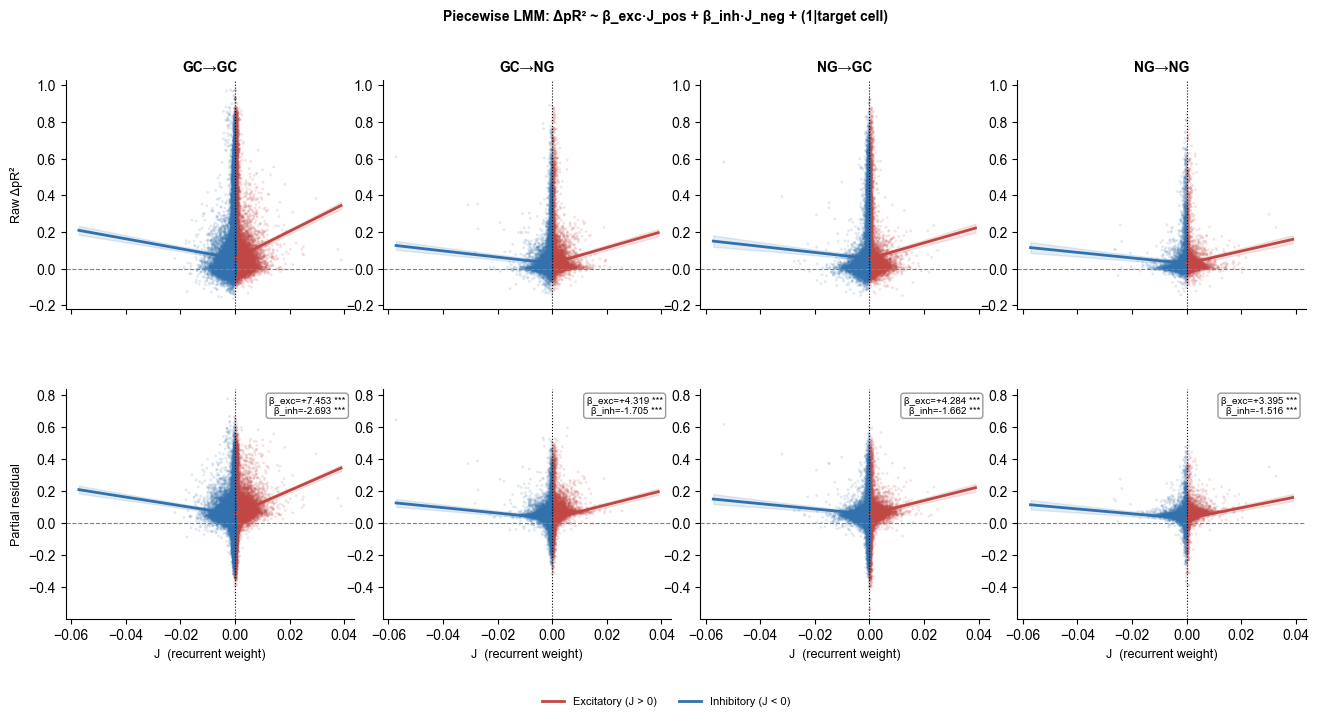

In [21]:
import statsmodels.formula.api as smf
import scipy.stats
from matplotlib.lines import Line2D

CONN_TYPES = ['GC→GC', 'GC→NG', 'NG→GC', 'NG→NG']
EXC_COL = '#c04744'
INH_COL = '#3171ae'

def fit_piecewise(df):
    results = {}
    for ct in CONN_TYPES:
        sub = df[df['conn_type'] == ct].copy()
        sub['J_pos'] = sub['J_raw'].clip(lower=0)
        sub['J_neg'] = sub['J_raw'].clip(upper=0)
        fit = smf.mixedlm("delta_pr2 ~ J_pos + J_neg", sub,
                           groups=sub['target_id']).fit(
                               reml=True, method='lbfgs', disp=False)
        results[ct] = {'fit': fit, 'sub': sub}
    return results

def piecewise_line_ci(fit, x_neg_range, x_pos_range, ci=0.95):
    b0  = fit.params['Intercept']
    cov = fit.cov_params()
    tc  = scipy.stats.t.ppf((1 + ci) / 2, df=fit.nobs - 2)

    def segment(x, key):
        y  = b0 + fit.params[key] * x
        X  = np.column_stack([np.ones_like(x), x])
        C  = cov.loc[['Intercept', key], ['Intercept', key]].values
        se = np.sqrt((X @ C * X).sum(axis=1))
        return y, tc * se

    x_n = np.linspace(x_neg_range, 0, 150)
    x_p = np.linspace(0, x_pos_range, 150)
    y_n, ci_n = segment(x_n, 'J_neg')
    y_p, ci_p = segment(x_p, 'J_pos')
    return x_n, y_n, ci_n, x_p, y_p, ci_p

def pstar(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

print('Fitting piecewise LMMs...')
res_tr = fit_piecewise(df_tr)

j_all = np.concatenate([res_tr[ct]['sub']['J_raw'].values for ct in CONN_TYPES])
j_min, j_max = j_all.min(), j_all.max()

# ── Figure: row 0 = raw ΔpR², row 1 = partial residual ───────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7),
                          sharex=True,
                          gridspec_kw={'hspace': 0.35, 'wspace': 0.10})

ROW_LABELS = ['Raw ΔpR²', 'Partial residual']

for col, ct in enumerate(CONN_TYPES):
    sub = res_tr[ct]['sub']
    fit = res_tr[ct]['fit']
    jv  = sub['J_raw'].values
    pos_mask = jv >= 0
    neg_mask = jv < 0

    x_n, y_n, ci_n, x_p, y_p, ci_p = piecewise_line_ci(fit, j_min, j_max)
    b_exc = fit.params['J_pos']; p_exc = fit.pvalues['J_pos']
    b_inh = fit.params['J_neg']; p_inh = fit.pvalues['J_neg']
    stats_txt = (f'β_exc={b_exc:+.3f} {pstar(p_exc)}\n'
                 f'β_inh={b_inh:+.3f} {pstar(p_inh)}')

    for row, y_vals in enumerate([sub['delta_pr2'].values,
                                   sub['partial_y'].values]):
        ax = axes[row, col]

        ax.scatter(jv[pos_mask], y_vals[pos_mask], s=4, alpha=0.15,
                   color=EXC_COL, edgecolors='none', rasterized=True)
        ax.scatter(jv[neg_mask], y_vals[neg_mask], s=4, alpha=0.15,
                   color=INH_COL, edgecolors='none', rasterized=True)

        ax.plot(x_n, y_n, color=INH_COL, lw=2)
        ax.plot(x_p, y_p, color=EXC_COL, lw=2)
        ax.fill_between(x_n, y_n - ci_n, y_n + ci_n, color=INH_COL, alpha=0.13)
        ax.fill_between(x_p, y_p - ci_p, y_p + ci_p, color=EXC_COL, alpha=0.13)

        ax.axhline(0, color='grey', lw=0.8, ls='--')
        ax.axvline(0, color='k',    lw=0.8, ls=':')
        ax.spines[['top', 'right']].set_visible(False)

        # Stats annotation only on partial residual row (where the model applies)
        if row == 1:
            ax.text(0.97, 0.97, stats_txt,
                    transform=ax.transAxes, fontsize=7, va='top', ha='right',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.8))

        if row == 0:
            ax.set_title(ct, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(ROW_LABELS[row], fontsize=9)
        if row == 1:
            ax.set_xlabel('J  (recurrent weight)', fontsize=9)

# Sync y-axes within each row independently
for row in range(2):
    ymin = min(ax.get_ylim()[0] for ax in axes[row])
    ymax = max(ax.get_ylim()[1] for ax in axes[row])
    for ax in axes[row]:
        ax.set_ylim(ymin, ymax)

handles = [
    Line2D([0],[0], color=EXC_COL, lw=2, label='Excitatory (J > 0)'),
    Line2D([0],[0], color=INH_COL, lw=2, label='Inhibitory (J < 0)'),
]
fig.legend(handles=handles, fontsize=8, frameon=False,
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Piecewise LMM: ΔpR² ~ β_exc·J_pos + β_inh·J_neg + (1|target cell)',
             fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('piecewise_lmm_raw_vs_partial.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


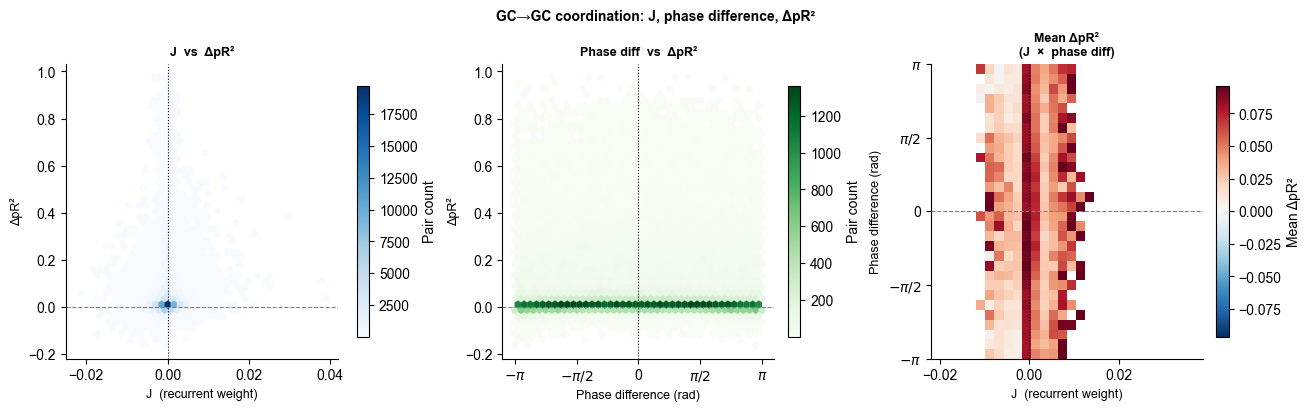

In [23]:
from scipy.stats import binned_statistic_2d

# ── Phase for each GC in rm_order position ────────────────────────────────────
phase_sorted = phase_gc[gc_phase_order]   # shape (n_gc_rm,)

gc_gc = df_tr[df_tr['conn_type'] == 'GC→GC'].copy()
gc_gc['phase_t']    = gc_gc['target_id'].astype(int).map(lambda i: phase_sorted[i])
gc_gc['phase_s']    = gc_gc['source_id'].astype(int).map(lambda j: phase_sorted[j])
raw_diff            = gc_gc['phase_t'].values - gc_gc['phase_s'].values
gc_gc['phase_diff'] = (raw_diff + np.pi) % (2 * np.pi) - np.pi   # wrap to [-π, π]

jv   = gc_gc['J_raw'].values
dpR2 = gc_gc['delta_pr2'].values
pd_  = gc_gc['phase_diff'].values

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0), constrained_layout=True)

# ── 1. J vs ΔpR² hexbin ──────────────────────────────────────────────────────
ax = axes[0]
hb = ax.hexbin(jv, dpR2, gridsize=40, cmap='Blues', mincnt=1, linewidths=0.2)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.axvline(0, color='k',    lw=0.8, ls=':')
ax.set_xlabel('J  (recurrent weight)', fontsize=9)
ax.set_ylabel('ΔpR²', fontsize=9)
ax.set_title('J  vs  ΔpR²', fontsize=9, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.colorbar(hb, ax=ax, label='Pair count', shrink=0.85)

# ── 2. Phase difference vs ΔpR² hexbin ───────────────────────────────────────
ax = axes[1]
hb2 = ax.hexbin(pd_, dpR2, gridsize=40, cmap='Greens', mincnt=1, linewidths=0.2)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.axvline(0, color='k',    lw=0.8, ls=':')
ax.set_xlabel('Phase difference (rad)', fontsize=9)
ax.set_ylabel('ΔpR²', fontsize=9)
ax.set_title('Phase diff  vs  ΔpR²', fontsize=9, fontweight='bold')
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
ax.spines[['top', 'right']].set_visible(False)
plt.colorbar(hb2, ax=ax, label='Pair count', shrink=0.85)

# ── 3. 2D heatmap: J × phase_diff → mean ΔpR² ───────────────────────────────
ax = axes[2]
N_J = 30; N_PH = 30

mean_stat, j_edges, ph_edges, _ = binned_statistic_2d(
    jv, pd_, dpR2, statistic='mean', bins=[N_J, N_PH],
    range=[[jv.min(), jv.max()], [-np.pi, np.pi]])
count_stat, _, _, _ = binned_statistic_2d(
    jv, pd_, dpR2, statistic='count', bins=[N_J, N_PH],
    range=[[jv.min(), jv.max()], [-np.pi, np.pi]])

mean_stat[count_stat < 5] = np.nan   # mask sparse bins
vabs = np.nanpercentile(np.abs(mean_stat), 95)

im = ax.imshow(mean_stat.T, origin='lower', aspect='auto',
               extent=[j_edges[0], j_edges[-1], -np.pi, np.pi],
               cmap='RdBu_r', vmin=-vabs, vmax=vabs)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.axvline(0, color='k',    lw=0.8, ls=':')
ax.set_xlabel('J  (recurrent weight)', fontsize=9)
ax.set_ylabel('Phase difference (rad)', fontsize=9)
ax.set_title('Mean ΔpR²\n(J  ×  phase diff)', fontsize=9, fontweight='bold')
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
ax.spines[['top', 'right']].set_visible(False)
plt.colorbar(im, ax=ax, label='Mean ΔpR²', shrink=0.85)

fig.suptitle('GC→GC coordination: J, phase difference, ΔpR²',
             fontsize=10, fontweight='bold')
plt.savefig(os.path.join(CACHE_DIR, 'gcgc_phase_J_dpr2.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()


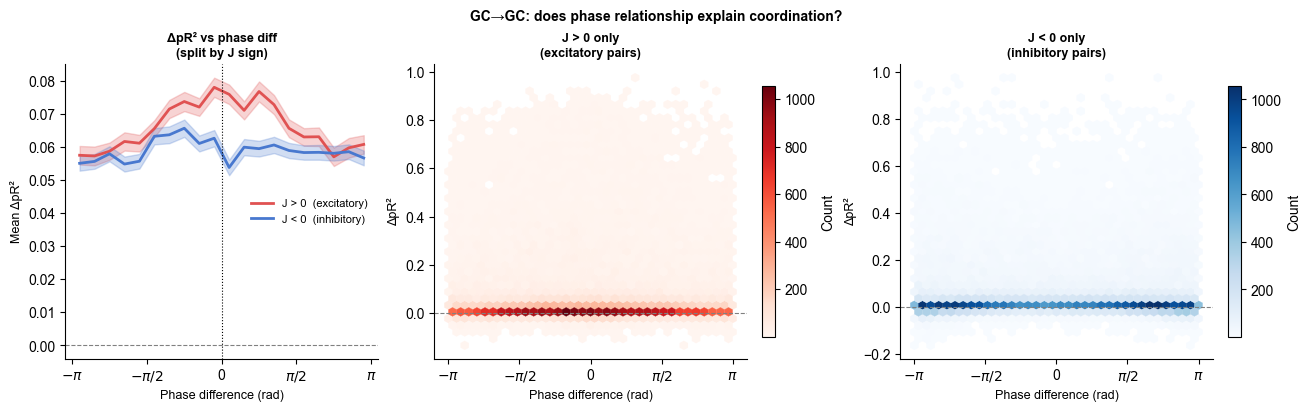

: 

In [ ]:
from scipy.stats import binned_statistic

gc_gc = df_tr[df_tr['conn_type'] == 'GC→GC'].copy()
phase_sorted = phase_gc[gc_phase_order]

gc_gc['phase_t']    = gc_gc['target_id'].astype(int).map(lambda i: phase_sorted[i])
gc_gc['phase_s']    = gc_gc['source_id'].astype(int).map(lambda j: phase_sorted[j])
raw_diff            = gc_gc['phase_t'].values - gc_gc['phase_s'].values
gc_gc['phase_diff'] = (raw_diff + np.pi) % (2 * np.pi) - np.pi

exc = gc_gc[gc_gc['J_raw'] > 0]
inh = gc_gc[gc_gc['J_raw'] < 0]

PH_BINS = 20
ph_edges = np.linspace(-np.pi, np.pi, PH_BINS + 1)
ph_centres = (ph_edges[:-1] + ph_edges[1:]) / 2

def bin_mean_sem(df, edges):
    means, sems = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        v = df.loc[(df['phase_diff'] >= lo) & (df['phase_diff'] < hi), 'delta_pr2'].values
        means.append(v.mean() if len(v) > 0 else np.nan)
        sems.append(v.std() / np.sqrt(len(v)) if len(v) > 1 else np.nan)
    return np.array(means), np.array(sems)

exc_mean, exc_sem = bin_mean_sem(exc, ph_edges)
inh_mean, inh_sem = bin_mean_sem(inh, ph_edges)

# ── Figure: 3 panels ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0), constrained_layout=True)

EXC_COL = '#e05252'
INH_COL = '#4878cf'

# ── Panel 1: mean ΔpR² vs phase_diff, split by J sign ────────────────────────
ax = axes[0]
ax.plot(ph_centres, exc_mean, color=EXC_COL, lw=2, label='J > 0  (excitatory)')
ax.fill_between(ph_centres, exc_mean - exc_sem, exc_mean + exc_sem,
                color=EXC_COL, alpha=0.25)
ax.plot(ph_centres, inh_mean, color=INH_COL, lw=2, label='J < 0  (inhibitory)')
ax.fill_between(ph_centres, inh_mean - inh_sem, inh_mean + inh_sem,
                color=INH_COL, alpha=0.25)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.axvline(0, color='k',    lw=0.8, ls=':')
ax.set_xlabel('Phase difference (rad)', fontsize=9)
ax.set_ylabel('Mean ΔpR²', fontsize=9)
ax.set_title('ΔpR² vs phase diff\n(split by J sign)', fontsize=9, fontweight='bold')
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

# ── Panel 2: hexbin phase_diff vs ΔpR² for J > 0 (excitatory only) ───────────
ax = axes[1]
hb = ax.hexbin(exc['phase_diff'].values, exc['delta_pr2'].values,
               gridsize=35, cmap='Reds', mincnt=1, linewidths=0.2)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel('Phase difference (rad)', fontsize=9)
ax.set_ylabel('ΔpR²', fontsize=9)
ax.set_title('J > 0 only\n(excitatory pairs)', fontsize=9, fontweight='bold')
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
ax.spines[['top', 'right']].set_visible(False)
plt.colorbar(hb, ax=ax, label='Count', shrink=0.85)

# ── Panel 3: hexbin phase_diff vs ΔpR² for J < 0 (inhibitory only) ───────────
ax = axes[2]
hb2 = ax.hexbin(inh['phase_diff'].values, inh['delta_pr2'].values,
                gridsize=35, cmap='Blues', mincnt=1, linewidths=0.2)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel('Phase difference (rad)', fontsize=9)
ax.set_ylabel('ΔpR²', fontsize=9)
ax.set_title('J < 0 only\n(inhibitory pairs)', fontsize=9, fontweight='bold')
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
ax.spines[['top', 'right']].set_visible(False)
plt.colorbar(hb2, ax=ax, label='Count', shrink=0.85)

fig.suptitle('GC→GC: does phase relationship explain coordination?',
             fontsize=10, fontweight='bold')
plt.savefig(os.path.join(CACHE_DIR, 'gcgc_phase_by_sign.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()


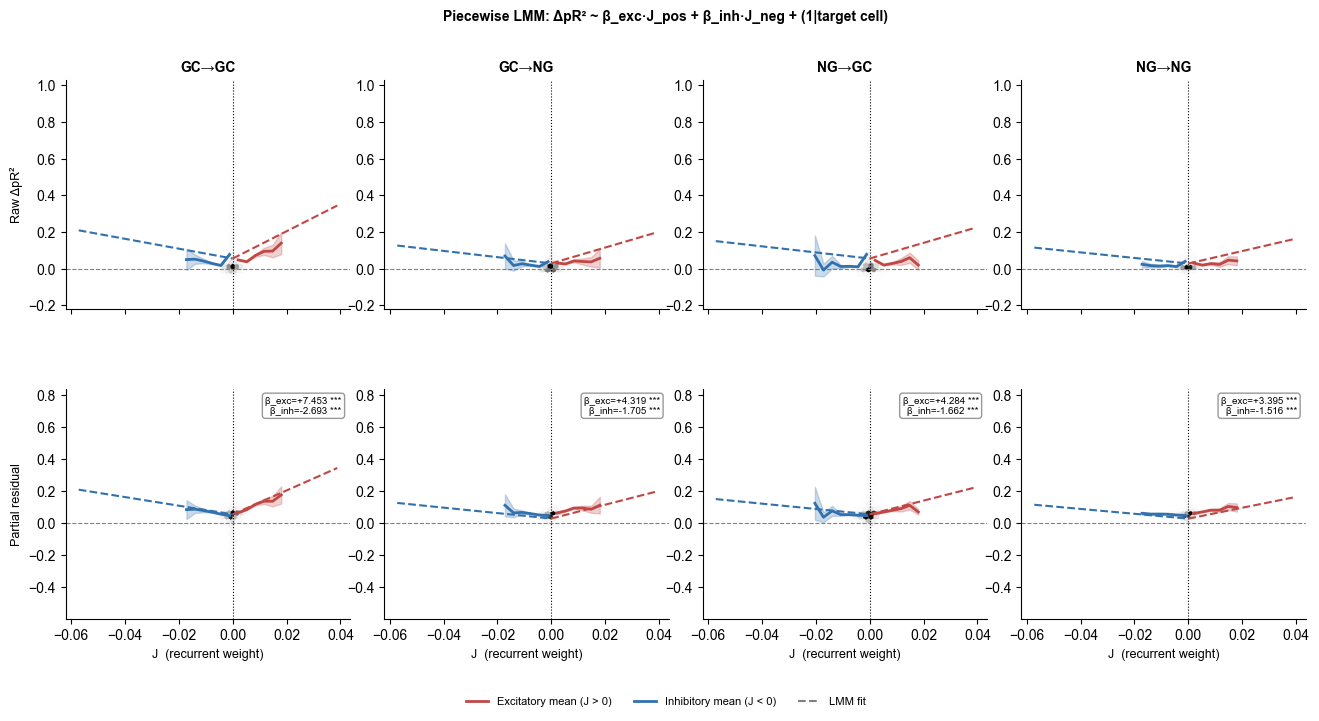

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7),
                          sharex=True,
                          gridspec_kw={'hspace': 0.35, 'wspace': 0.12})

N_BINS = 30   # J bins for the mean line

for col, ct in enumerate(CONN_TYPES):
    sub = res_tr[ct]['sub']
    fit = res_tr[ct]['fit']
    jv  = sub['J_raw'].values

    x_n, y_n, ci_n, x_p, y_p, ci_p = piecewise_line_ci(fit, j_min, j_max)
    b_exc = fit.params['J_pos']; p_exc = fit.pvalues['J_pos']
    b_inh = fit.params['J_neg']; p_inh = fit.pvalues['J_neg']
    stats_txt = (f'β_exc={b_exc:+.3f} {pstar(p_exc)}\n'
                 f'β_inh={b_inh:+.3f} {pstar(p_inh)}')

    for row, y_vals in enumerate([sub['delta_pr2'].values,
                                   sub['partial_y'].values]):
        ax = axes[row, col]

        # ── Hexbin density ────────────────────────────────────────────────────
        hb = ax.hexbin(jv, y_vals, gridsize=40, cmap='Greys',
                       mincnt=1, linewidths=0.2)

        # ── Binned mean ± SEM overlaid ────────────────────────────────────────
        bin_edges = np.linspace(j_min, j_max, N_BINS + 1)
        bin_idx   = np.digitize(jv, bin_edges) - 1
        bin_means, bin_cis, bin_centres = [], [], []
        for b in range(N_BINS):
            mask = bin_idx == b
            if mask.sum() < 5:
                continue
            vals = y_vals[mask]
            bin_centres.append((bin_edges[b] + bin_edges[b+1]) / 2)
            bin_means.append(vals.mean())
            bin_cis.append(1.96 * vals.std() / np.sqrt(mask.sum()))
        bin_centres = np.array(bin_centres)
        bin_means   = np.array(bin_means)
        bin_cis     = np.array(bin_cis)

        # Colour mean line by sign of J
        pos_b = bin_centres >= 0; neg_b = bin_centres < 0
        ax.plot(bin_centres[pos_b], bin_means[pos_b], color=EXC_COL, lw=2, zorder=5)
        ax.plot(bin_centres[neg_b], bin_means[neg_b], color=INH_COL, lw=2, zorder=5)
        ax.fill_between(bin_centres[pos_b],
                        bin_means[pos_b] - bin_cis[pos_b],
                        bin_means[pos_b] + bin_cis[pos_b],
                        color=EXC_COL, alpha=0.25, zorder=4)
        ax.fill_between(bin_centres[neg_b],
                        bin_means[neg_b] - bin_cis[neg_b],
                        bin_means[neg_b] + bin_cis[neg_b],
                        color=INH_COL, alpha=0.25, zorder=4)

        # ── LMM fit line ──────────────────────────────────────────────────────
        ax.plot(x_n, y_n, color=INH_COL, lw=1.5, ls='--', zorder=6)
        ax.plot(x_p, y_p, color=EXC_COL, lw=1.5, ls='--', zorder=6)

        ax.axhline(0, color='grey', lw=0.8, ls='--')
        ax.axvline(0, color='k',    lw=0.8, ls=':')
        ax.spines[['top', 'right']].set_visible(False)

        if row == 1:
            ax.text(0.97, 0.97, stats_txt,
                    transform=ax.transAxes, fontsize=7, va='top', ha='right',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.8))
        if row == 0:
            ax.set_title(ct, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(ROW_LABELS[row], fontsize=9)
        if row == 1:
            ax.set_xlabel('J  (recurrent weight)', fontsize=9)

for row in range(2):
    ymin = min(ax.get_ylim()[0] for ax in axes[row])
    ymax = max(ax.get_ylim()[1] for ax in axes[row])
    for ax in axes[row]:
        ax.set_ylim(ymin, ymax)

handles = [
    Line2D([0],[0], color=EXC_COL, lw=2, label='Excitatory mean (J > 0)'),
    Line2D([0],[0], color=INH_COL, lw=2, label='Inhibitory mean (J < 0)'),
    Line2D([0],[0], color='grey',   lw=1.5, ls='--', label='LMM fit'),
]
fig.legend(handles=handles, fontsize=8, frameon=False,
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Piecewise LMM: ΔpR² ~ β_exc·J_pos + β_inh·J_neg + (1|target cell)',
             fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('piecewise_lmm_hexbin.pdf',
            bbox_inches='tight', dpi=300)
plt.show()


# Two-network disconnected control

Does ΔpR² approximate functional coupling? We combine two **functionally disconnected** grid
RNNs (net 1 = pretrained Ng=4096, net 2 = independent Ng=1024) driven on the **same trajectories**.
Cross-network cell pairs share position/velocity drive but have **zero coupling** (block-diagonal J).

Baseline = position + speed + head direction (all recovered from the shared velocity input).
- **pR²(cell)** — one cell predicting another — is confounded by shared spatial coding.
- **ΔpR² = pR²(baseline+cell) − pR²(baseline)** should isolate coupling: high *within* a network
  (tracks |J|), ~0 *across* networks.

Cache built by `build_two_net_cache.py` → `pr2_two_network_cache.npz`.

In [ ]:
# ── Four matrices: ground-truth J vs XGBoost predictability (network-ordered) ─
import matplotlib
DATA_DIR = "/Users/harryclark/Documents/spatial-manifolds/data/rnn_xgboost"
FIG_DIR  = "/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_validations"
CACHE2   = DATA_DIR + "/pr2_two_network_cache.npz"
if not os.path.exists(CACHE2):
    print("Cache not found yet — run build_two_net_cache.py.")
else:
    c2 = np.load(CACHE2, allow_pickle=True)
    pr2_base, pr2_cell, pr2_full = c2["pr2_base"], c2["pr2_cell"], c2["pr2_full"]
    net_id, J, K = c2["net_id"], c2["J_comb"], int(c2["K"])
    N = len(net_id)

    # All matrices oriented [target (post, row), source (pre, col)] to match J.
    Jmat  = J.copy()
    Cell  = pr2_cell.T.copy()
    Full  = pr2_full.T.copy()
    Delta = (pr2_full - pr2_base[None, :]).T.copy()
    low   = np.where(pr2_base < 0.3)[0]                # spatially-unpredictable targets
    for M in (Cell, Full, Delta): np.fill_diagonal(M, np.nan)
    Delta[low, :] = np.nan                            # grey out excluded target rows

    W, X = "#c04744", "#3171ae"
    def blocks(ax, title):
        ax.axhline(K-0.5, color="k", lw=1.2); ax.axvline(K-0.5, color="k", lw=1.2)
        ax.set_xticks([]); ax.set_yticks([])
        for f, l, cc in [(0.25, "net1", W), (0.75, "net2", X)]:
            ax.text(N*f, N+3, l, ha="center", va="top", fontsize=7, fontweight="bold", color=cc)
            ax.text(-3, N*f, l, ha="center", va="center", rotation=90, fontsize=7, fontweight="bold", color=cc)
        ax.set_title(title, fontsize=9, fontweight="bold", pad=6)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4.3))
    vmaxJ = np.percentile(np.abs(Jmat[Jmat != 0]), 99)
    im = axes[0].imshow(Jmat, cmap="RdBu_r", vmin=-vmaxJ, vmax=vmaxJ, interpolation="nearest")
    blocks(axes[0], "J  (ground-truth coupling)")
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.02)
    for ax, M, title, cmap, lo, hi in [
        (axes[1], Cell,  "pR²(cell)",             "viridis", 0, np.nanpercentile(Cell, 99)),
        (axes[2], Full,  "pR²(base + cell)",      "viridis", np.nanpercentile(Full, 2), np.nanpercentile(Full, 98)),
        (axes[3], Delta, "ΔpR²  (base+cell − base)","inferno", 0, np.nanpercentile(Delta, 95))]:
        cm = matplotlib.colormaps[cmap].copy(); cm.set_bad("lightgrey")
        im = ax.imshow(M, cmap=cm, vmin=lo, vmax=hi, interpolation="nearest")
        blocks(ax, title)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    fig.text(0.5, 0.02, "rows = target (post-synaptic)   |   cols = source (pre-synaptic)   |   base = position + speed + head direction   |   grey = self or excluded (pr2_base<0.3)",
             ha="center", fontsize=8, color="#555")
    fig.suptitle("Two-network control: ground-truth J vs XGBoost predictability matrices (network-ordered)",
                 fontsize=11, fontweight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.savefig(os.path.join(FIG_DIR, "two_network_matrices.pdf"), bbox_inches="tight")
    plt.savefig(os.path.join(FIG_DIR, "two_network_matrices.png"), dpi=120, bbox_inches="tight")
    plt.show()

In [ ]:
# ── Validate BOTH networks: grid rate maps + path-integration decoding ───────
NET2_DIR = "/Users/harryclark/Documents/spatial-manifolds/data/rnn_xgboost/second_net_seed1234_Ng1024"

# Build net 2 (Ng=1024) sharing net 1's place-cell centers
class _O2: pass
o2 = _O2()
for _k, _v in vars(options).items(): setattr(o2, _k, _v)
o2.Ng = 1024
place_cells2 = PlaceCells(o2); place_cells2.us = place_cells.us
model2 = RNN(o2, place_cells2).to(options.device)
model2.load_state_dict(torch.load(os.path.join(NET2_DIR, "ckpt.pth"),
                                  map_location=options.device)["model"])
model2.eval()
print("net 2 loaded (Ng=1024)")

def _grid_scores(mdl, opts, n_rm):
    a, _, _, _ = compute_ratemaps(mdl, trajectory_generator, opts, res=RES, n_avg=N_AVG, Ng=n_rm)
    sc = np.array([scorer.get_scores(a[ni])[0] for ni in range(n_rm)])
    return a, sc

act1, sc1 = _grid_scores(model,  options, 512)
act2, sc2 = _grid_scores(model2, o2,      o2.Ng)
ord1, ord2 = np.argsort(sc1)[::-1], np.argsort(sc2)[::-1]

# ── Rate maps: top grid cells from each network ──────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(15, 3.3))
for row, (act, order, sc, lab, col) in enumerate([
        (act1, ord1, sc1, "net 1 (4096)", "#c04744"),
        (act2, ord2, sc2, "net 2 (1024)", "#3171ae")]):
    for c in range(10):
        ax = axes[row, c]; ni = order[c]; rm = act[ni]
        ax.imshow(rm.T, origin="lower", cmap="viridis",
                  vmin=0, vmax=max(np.nanpercentile(rm, 99), 1e-4), interpolation="gaussian")
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values(): s.set_visible(False)
        ax.set_title(f"{sc[ni]:.2f}", fontsize=6)
        if c == 0:
            ax.set_ylabel(lab, fontsize=8, color=col, fontweight="bold")
FIG_DIR = "/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_validations"
fig.suptitle("Top grid cells — both networks form hexagonal grids", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "two_network_grids.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(FIG_DIR, "two_network_grids.png"), dpi=120, bbox_inches="tight")
plt.show()

# ── Decoded vs true position for each network ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4.6))
for ax, (mdl, pc_, lab) in zip(axes, [(model, place_cells, "net 1 (4096)"),
                                      (model2, place_cells2, "net 2 (1024)")]):
    mdl.eval()
    with torch.no_grad():
        inp, pos, _ = trajectory_generator.get_test_batch()
        pred = pc_.get_nearest_cell_pos(mdl.predict(inp)).cpu()
    pos = pos.cpu(); err = torch.sqrt(((pos - pred) ** 2).sum(-1)).mean().item() * 100
    for i in range(5):
        ax.plot(pos[:, i, 0], pos[:, i, 1], c="k", lw=2, label="true" if i == 0 else None)
        ax.plot(pred[:, i, 0], pred[:, i, 1], ".-", c="C1", label="decoded" if i == 0 else None)
    us = pc_.us.cpu()
    ax.scatter(us[:, 0], us[:, 1], s=8, alpha=0.3, c="lightgrey")
    ax.set_xlim(-options.box_width/2, options.box_width/2)
    ax.set_ylim(-options.box_height/2, options.box_height/2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{lab}  |  {err:.1f} cm", fontsize=9)
    ax.legend(fontsize=7, frameon=False)
fig.suptitle("Path integration — decoded vs true position", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "two_network_decoding.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(FIG_DIR, "two_network_decoding.png"), dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# ── Does ΔpR² recover coupling? (base-filtered; within vs cross) ─────────────
from scipy.stats import spearmanr
import matplotlib.patches as mpatches
DATA_DIR = "/Users/harryclark/Documents/spatial-manifolds/data/rnn_xgboost"
CACHE2   = DATA_DIR + "/pr2_two_network_cache.npz"
FIG_DIR = "/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_validations"
BASE_MIN = 0.3   # exclude spatially-unpredictable target cells (pr2_base below this)

c2 = np.load(CACHE2, allow_pickle=True)
pr2_base, pr2_cell, pr2_full = c2["pr2_base"], c2["pr2_cell"], c2["pr2_full"]
completed, J_comb, net_id, K = c2["completed"], c2["J_comb"], c2["net_id"], int(c2["K"])
N = len(net_id)
low = pr2_base < BASE_MIN
print(f"{int(completed.sum())}/{N} targets complete | "
      f"excluded {int(low.sum())} low-baseline targets: {np.where(low)[0].tolist()}")

rows = []
for ti in range(N):
    if not completed[ti] or low[ti]: continue
    for ci in range(N):
        if ci == ti or np.isnan(pr2_full[ci, ti]): continue
        rows.append((abs(float(J_comb[ti, ci])), float(pr2_cell[ci, ti]),
                     float(pr2_full[ci, ti] - pr2_base[ti]), bool(net_id[ci] == net_id[ti])))
absJ, pcell, dpr2, within = (np.array([r[k] for r in rows]) for k in range(4))
within = within.astype(bool)
W, X = "#c04744", "#3171ae"

fig, ax = plt.subplots(1, 3, figsize=(14, 4.3))

# Panel 1: ΔpR² vs |J| quintile (within) with cross-net floor
wj, wd = absJ[within], dpr2[within]
q = np.quantile(wj, np.linspace(0, 1, 6))
cy = [wd[(wj >= q[i]) & (wj <= q[i+1])].mean() for i in range(5)]
ce = [wd[(wj >= q[i]) & (wj <= q[i+1])].std() / np.sqrt(max(((wj >= q[i]) & (wj <= q[i+1])).sum(), 1)) for i in range(5)]
ax[0].errorbar(range(5), cy, yerr=ce, marker="o", color=W, lw=2, capsize=3, label="within-net (J≠0)")
floor = dpr2[~within].mean()
ax[0].axhline(floor, color=X, lw=2, ls="--", label="cross-net floor (J=0)")
ax[0].set_xticks(range(5)); ax[0].set_xticklabels(["Q1","Q2","Q3","Q4","Q5"])
ax[0].set_xlabel("|J| quintile (within-net)"); ax[0].set_ylabel("ΔpR²")
rho, pval = spearmanr(wj, wd)
ax[0].set_title(f"ΔpR² rises with |J|\nSpearman={rho:+.2f}, p={pval:.0e}", fontsize=9, fontweight="bold")
ax[0].legend(fontsize=8, frameon=False); ax[0].spines[["top","right"]].set_visible(False)

# Panel 2: unbiasedness — ΔpR² vs pR²(cell), within vs cross (cross truth = 0)
data = [dpr2[within], dpr2[~within], pcell[within], pcell[~within]]
parts = ax[1].violinplot(data, positions=[0,0.55,1.7,2.25], widths=0.45, showmeans=True)
for b, cc in zip(parts["bodies"], [W,X,W,X]): b.set_facecolor(cc); b.set_alpha(0.5)
ax[1].axhline(0, color="k", lw=0.8, ls=":")
ax[1].set_xticks([0.27,1.97]); ax[1].set_xticklabels(["ΔpR²","pR²(cell)"]); ax[1].set_ylabel("value")
ax[1].set_title(f"cross ΔpR²={dpr2[~within].mean():.3f} (≈0)\nvs cross pR²(cell)={pcell[~within].mean():.3f}",
                fontsize=9, fontweight="bold")
ax[1].legend([mpatches.Patch(color=W,alpha=.5),mpatches.Patch(color=X,alpha=.5)],["within","cross"],fontsize=8,frameon=False)
ax[1].spines[["top","right"]].set_visible(False)

# Panel 3: correlation-with-|J| — ΔpR² isolates coupling, pR²(cell) inflated by shared tuning
r_d = spearmanr(absJ[within], dpr2[within])[0]; r_c = spearmanr(absJ[within], pcell[within])[0]
ax[2].bar([0,1], [r_d, r_c], color=[W,"#888"], width=0.6)
ax[2].set_xticks([0,1]); ax[2].set_xticklabels(["ΔpR²","pR²(cell)"])
ax[2].set_ylabel("within-net Spearman(|J|, ·)")
for xx, vv in [(0,r_d),(1,r_c)]: ax[2].text(xx, vv+0.008, f"{vv:.2f}", ha="center", fontsize=9)
hi = within & (absJ >= np.quantile(absJ[within], 0.9))
ax[2].set_title(f"strong (top-10% |J|) within ΔpR²\n= {dpr2[hi].mean()/max(floor,1e-9):.1f}× cross floor",
                fontsize=9, fontweight="bold")
ax[2].spines[["top","right"]].set_visible(False); ax[2].set_ylim(0, max(r_d,r_c)*1.25)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "two_network_control.pdf"), bbox_inches="tight", dpi=150)
plt.savefig(os.path.join(FIG_DIR, "two_network_control.png"), bbox_inches="tight", dpi=120)
plt.show()

print(f"within ΔpR²={dpr2[within].mean():.4f}  cross ΔpR²={dpr2[~within].mean():.4f}  "
      f"ratio={dpr2[within].mean()/max(dpr2[~within].mean(),1e-9):.2f}x")
print(f"Spearman(|J|,ΔpR²)={r_d:+.3f}   Spearman(|J|,pR²cell)={r_c:+.3f}")